# The alert router — the whole pipeline

One gzipped JSONL export of SOAR containers goes in; a frozen, fingerprinted
**binary classifier** comes out.

## What it classifies

**Is this alert a Benign Positive, or is it something else?**

That is the whole question. A Benign Positive is suspicious-but-expected activity
that a human looked at and closed as fine. Anything else — a real incident, a
broken detection, bad data — is *not* a Benign Positive.

| Disposition | Class | `not_benign` |
| --- | --- | ---: |
| Benign Positive — Suspicious But Expected | benign | 0 |
| True Positive — Suspicious Activity | not benign | 1 |
| False Positive — Incorrect Analytic Logic | not benign | 1 |
| False Positive — Inaccurate Data | not benign | 1 |

The routing follows from the classification and adds nothing to it:

> **Benign Positive → the AI closes it. Not a Benign Positive → a human looks.**

So the model outputs `P(not benign)`, and a threshold on that probability decides
who gets the alert. Everything else in this notebook is about producing that one
number honestly and choosing that one threshold responsibly.

## The stages

Everything the pipeline does lives in this notebook — there is no library to read
alongside it.

| Stage | What it decides |
| --- | --- |
| 1 | what is in the export, and which records carry a label |
| 2 | which artifact *is* the alert, and how it becomes text |
| 3 | the label, the ordering, and the split |
| 4 | the estimator |
| 5 | evaluation, operating points, and the frozen release |
| 6 | classifying one alert, end to end |

Kernel: **AI-SOC training pipeline** — the `.venv` in this folder.

In [1]:
import collections, gzip, hashlib, json, platform, re, textwrap, time

import yaml
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline

pd.set_option("display.max_colwidth", 88)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 130)

HERE      = Path.cwd()
SOURCE    = HERE.parent.parent / "soar-containers-12mo-20260923.jsonl.gz"
ARTIFACTS = HERE / "artifacts"; ARTIFACTS.mkdir(exist_ok=True)

print("python      ", platform.python_version())
print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print()
print("source      ", SOURCE)
print("exists      ", SOURCE.exists(), f"— {SOURCE.stat().st_size/1e6:,.0f} MB")

python       3.14.4
pandas       3.0.6
numpy        2.5.3
scikit-learn 1.9.1

source       /Users/mohammad.yekrangian/Projects/poc/apollo/triage/soar-containers-12mo-20260923.jsonl.gz
exists       True — 117 MB


---
## Configuration — the four decisions, in one place

Everything the pipeline throws away is declared here rather than buried in a
function, so the exclusions can be read as a list.

In [2]:
# ---------------------------------------------------------------- the label
# The four verdicts that are a label, mapped to the three classes we model.
#
# A `disposition` is a human's ruling on a closed container. `Other` is the
# heartbeat/duplicate bucket, `Undetermined` is an analyst who looked and could
# not rule it, and a null was never dispositioned. None of the three is a
# statement about the alert, so none of them can supervise a model.
KEEP = {
    "True Positive - Suspicious Activity":       "True Positive",
    "False Positive - Incorrect Analytic Logic": "False Positive",
    "False Positive - Inaccurate Data":          "False Positive",
    "Benign Positive - Suspicious But Expected": "Benign Positive",
}

# The classifier is Benign Positive vs everything else.
#
#   0 = Benign Positive  — suspicious but expected; the AI can close it
#   1 = not benign       — True Positive or False Positive; a human looks
#
# False Positive sits with True Positive because it is still not benign: it needs
# a human *action*, a detection fix rather than a response. Keeping class 0 to
# Benign Positive alone is what makes the negative class mean one clean thing.
NOT_BENIGN   = {"Benign Positive": 0, "True Positive": 1, "False Positive": 1}
TARGET = "not_benign"
INPUT  = "text_cef"      # the one column the estimator reads

# ------------------------------------------------- keys dropped from the alert
# Splunk plumbing, per-event identifiers, and ES-side triage state.
#
# A bucket id or a search id is unique to one alert, so it can only ever be noise
# or a memorised handle on a single training row — never a pattern that transfers.
# `status` and `owner` are worse than useless: they describe the triage state,
# which moves *after* the alert arrives.
# Loaded from ../config/preprocessing.json, the single file both this notebook
# and the serving API read. Every release records its sha256, so a model states
# which rules it was built with. 44 keys in 7 groups, each with its reason:
#
#   splunk_plumbing        internal storage handles
#   per_event_identifiers  unique per alert - a handle, never a pattern
#   timestamps, date_parts encode WHEN, not WHAT
#   console_urls           per-alert links back into ES
#   triage_state           LEAKAGE - status/owner are set AFTER an analyst works it
#   serving_alignment      present on only one side of the SOAR/Apollo boundary
RELEASE = "v20"          # the release this notebook cuts and checks against

CFG = yaml.safe_load((Path.cwd().parent / "config" / "preprocessing.yaml").read_text())
DROP = {k for g in CFG["drop_keys"].values() for k in g["keys"]}

# The operating point lives in the same file but is NOT part of `rules_sha256`:
# recalibrating retrains nothing, so it must not invalidate a frozen release.
# Chosen by the Clopper-Pearson upper bound on the AI lane's error rate - see
# Stage 7 and ../calibrate.py.
THRESHOLD = CFG["operating_threshold"]["value"]
TOLERANCE = CFG["operating_threshold"]["tolerance"]

# v20 fits only the fields Apollo has actually been observed to forward - the
# intersection of the training corpus and the live feed. Recomputed from a fresh
# export at every retraining by ../dataset_v20.py, not pinned.
APOLLO_KEYS = set(json.loads(
    (Path.cwd().parent / "config" / "apollo_keys.json").read_text())["keys"])

# A value that means "this field was not filled in".
NOT_A_VALUE = ("none", "null", "-", "unknown")

# ------------------------------------------------------ anything that encodes WHEN
# Matched on the VALUE, not the key. The blob carries timestamps in at least twenty
# differently-named fields (user_startDate, firstSeen, loginTime, drilldown_earliest)
# and dates embedded inside filenames and rule descriptions, so a key blocklist
# cannot catch them.
TIME_TOKEN = re.compile(CFG["scrub_time_values"]["pattern"], re.I)
_OLD = (
    r"20\d{2}[-/]\d{1,2}[-/]\d{1,2}(?:[T ][\d:.]+(?:Z|[+-]\d{2}:?\d{2})?)?"  # ISO
    r"|\b\d{9,}(?:\.\d+)?\b"                                                  # epochs, long ids
    r"|\b20[2-3]\d\b"                                                           # bare years
    r"|\b\d{1,2}:\d{2}(?::\d{2})?\b",                                         # clock times
    re.I)

SEED, ALPHA, AVERAGE, HOLDOUT = 7, 1e-5, True, 0.30

# ---------------------------------------------------------------- the guard
# The config is read from three places - these modules, this notebook, and the
# serving API - and only one of them had a test. This is the notebook's.
#
# `rules_sha256` fingerprints the sections that decide what the model is fitted
# on: artifact_selection, drop_keys, empty_values, scrub_time_values, rendering.
# `operating_threshold` is deliberately excluded, so recalibrating the threshold
# does not trip this.
#
# It fails in the first cell rather than after a two-minute run, and it fails
# loudly rather than silently training on rules the shipped model never used.
RULES = ("artifact_selection", "drop_keys", "empty_values",
         "scrub_time_values", "rendering")


def rules_sha256(config):
    return hashlib.sha256(json.dumps(
        {k: config[k] for k in RULES if k in config},
        sort_keys=True, separators=(",", ":"), default=str).encode()).hexdigest()


RULES_SHA = rules_sha256(CFG)
_manifest = Path.cwd().parent / "models" / RELEASE / "manifest.json"
if _manifest.exists():
    _recorded = json.loads(_manifest.read_text())["preprocessing"]["config_sha256"]
    assert _recorded == RULES_SHA, (
        f"preprocessing rules have changed since {RELEASE} was frozen\n"
        f"  config now : {RULES_SHA}\n"
        f"  {RELEASE} was cut with : {_recorded}\n"
        f"Either re-cut the release (../freeze.py --full --input text_{RELEASE} "
        f"--version {RELEASE}) or revert config/preprocessing.yaml. Training on "
        f"rules the shipped model never saw would produce a model that scores "
        f"differently in production than it does here.")
    print(f"rules sha {RULES_SHA[:16]}... matches {RELEASE}'s manifest")
else:
    print(f"rules sha {RULES_SHA[:16]}...  ({RELEASE} not yet frozen - nothing to check)")

# the Apollo key list must also be the one the release was fitted on
_keys_file = Path.cwd().parent / "config" / "apollo_keys.json"
assert set(json.loads(_keys_file.read_text())["keys"]) == APOLLO_KEYS, \
    "config/apollo_keys.json changed after it was loaded"

# --- and the release's OWN frozen contract must agree with the working copy ---
# Each release carries models/<release>/preprocessing.yaml: the rules it was cut
# with, its feature definition and its own threshold. Serving reads THAT file,
# not this one, so a disagreement here means the notebook and the deployed
# service are working from different rules.
_release_cfg = Path.cwd().parent / "models" / RELEASE / "preprocessing.yaml"
if _release_cfg.exists():
    _frozen = yaml.safe_load(_release_cfg.read_text())
    assert rules_sha256(_frozen) == RULES_SHA, (
        f"models/{RELEASE}/preprocessing.yaml disagrees with config/preprocessing.yaml\n"
        f"  working copy : {RULES_SHA}\n"
        f"  {RELEASE} frozen  : {rules_sha256(_frozen)}\n"
        f"Serving reads the frozen file, so it would score a different string "
        f"than this notebook trains on.")
    _f = _frozen["features"]
    assert _f["input_column"] == f"text_{RELEASE}", _f
    _thr = _frozen["operating_threshold"]
    print(f"{RELEASE} contract: min_df {_f['tfidf_min_df']}  "
          f"keys {_f['key_list'] or 'all'}  threshold {_thr['value']}"
          f"{'' if _thr.get('calibrated', True) else '  (NOT calibrated)'}")
else:
    print(f"models/{RELEASE}/preprocessing.yaml missing - re-cut with freeze.py")

print()
print(f"{len(KEEP)} dispositions are a label")
print(f"{len(APOLLO_KEYS):,} fields Apollo forwards -> the model is fitted on these")
print(f"operating threshold {THRESHOLD} at a {TOLERANCE*100:.1f}% error tolerance")
print(f"{len(DROP)} keys dropped from every alert")
print(f"{len(NOT_A_VALUE)} values treated as empty: {NOT_A_VALUE}")

rules sha 4365700b56b37d32... matches v20's manifest
v20 contract: min_df 1  keys apollo_keys.json  threshold 0.007093

4 dispositions are a label
937 fields Apollo forwards -> the model is fitted on these
operating threshold 0.007093 at a 1.0% error tolerance
44 keys dropped from every alert
4 values treated as empty: ('none', 'null', '-', 'unknown')


---
# Stage 1 — what is actually in the export

Before any modelling decision, a census. This streams the whole file and counts
everything, **including the records that later get dropped**, so the drop is
visible as a number rather than as an absence.

In [3]:
def inventory(path=SOURCE, limit=None):
    """Stream the whole export and count what is in it.

    Deliberately makes no judgement — every disposition is counted, including the
    ones that get dropped.
    """
    inv = dict(records=0, labelled=0, unlabelled=0, no_close_time=0,
               top_level=collections.Counter(), dispositions=collections.Counter(),
               servers=collections.Counter(), artifact_counts=collections.Counter())
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if limit is not None and i >= limit:
                break
            rec = json.loads(line)
            inv["records"] += 1
            inv["top_level"].update(rec.keys())
            inv["dispositions"][rec.get("disposition") or "(never dispositioned)"] += 1
            inv["servers"][rec.get("server")] += 1
            inv["artifact_counts"][len(rec.get("CEF") or [])] += 1
            if rec.get("disposition") in KEEP:
                inv["labelled"] += 1
                inv["no_close_time"] += not rec.get("close_time")
            else:
                inv["unlabelled"] += 1
    return inv

t0 = time.time()
INV = inventory()
print(f"{INV['records']:,} containers   {SOURCE.stat().st_size/1e6:,.0f} MB on disk   "
      f"read in {time.time()-t0:.0f}s")

123,897 containers   117 MB on disk   read in 3s


## Every top-level key in the export, and whether the pipeline reads it

This is the whole surface area of the file. **Anything not marked `yes` is never
looked at by any stage.**

In [4]:
USED = {
    "server":      "half of the key — `id` repeats across servers",
    "id":          "the other half",
    "name":        "container name, fallback only",
    "disposition": "THE LABEL",
    "close_time":  "ordering and the split — when a human ruled it",
    "CEF":         "the artifact array; stage 2 picks one artifact out of it",
}

pd.DataFrame([{"key": k, "on_containers": n,
               "coverage_pct": round(n / INV["records"] * 100, 1),
               "read": "yes" if k in USED else "no",
               "used_for": USED.get(k, "")}
              for k, n in INV["top_level"].most_common()])

,key,on_containers,coverage_pct,read,used_for
0,server,123897,100.0,yes,half of the key — `id` repeats across servers
1,id,123897,100.0,yes,the other half
2,name,123897,100.0,yes,"container name, fallback only"
3,label,123897,100.0,no,
4,status,123897,100.0,no,
5,severity,123897,100.0,no,
6,sensitivity,123897,100.0,no,
7,container_type,123897,100.0,no,
8,owner_name,123897,100.0,no,
9,tenant,123897,100.0,no,


## Which containers carry a label

In [5]:
print(f"labelled   {INV['labelled']:,}")
print(f"dropped    {INV['unlabelled']:,}")
print(f"of the labelled, missing close_time: {INV['no_close_time']:,}\n")

pd.DataFrame([{"disposition": d, "containers": n,
               "share_pct": round(n / INV["records"] * 100, 2),
               "used_as": KEEP.get(d, "— dropped, not a verdict")}
              for d, n in INV["dispositions"].most_common()])

labelled   32,429
dropped    91,468
of the labelled, missing close_time: 2



,disposition,containers,share_pct,used_as
0,Other,46705,37.70,"— dropped, not a verdict"
1,(never dispositioned),43239,34.90,"— dropped, not a verdict"
2,Benign Positive - Suspicious But Expected,25965,20.96,Benign Positive
3,True Positive - Suspicious Activity,5723,4.62,True Positive
4,Undetermined,1523,1.23,"— dropped, not a verdict"
5,False Positive - Incorrect Analytic Logic,580,0.47,False Positive
6,False Positive - Inaccurate Data,161,0.13,False Positive
7,NA,1,0.00,"— dropped, not a verdict"


In [6]:
sizes = pd.Series(INV["artifact_counts"]).sort_index()
expanded = np.repeat(sizes.index.to_numpy(), sizes.to_numpy())
print("artifacts per container")
print(f"  with none : {int(sizes.get(0, 0)):,}")
print(f"  median    : {int(np.median(expanded))}      mean: {expanded.mean():.1f}"
      f"      max: {int(sizes.index.max())}")
print("\nSOAR servers")
for name, n in INV["servers"].most_common():
    print(f"  {name:14s} {n:7,}   ({n/INV['records']*100:4.1f}%)")

artifacts per container
  with none : 740
  median    : 3      mean: 3.3      max: 8410

SOAR servers
  prod-soar2      68,777   (55.5%)
  prod-soar       47,973   (38.7%)
  prod-soar3       7,147   ( 5.8%)


## Load the labelled containers

Filtering on the disposition *while streaming* is what keeps this in memory — the
`CEF` arrays are the bulk of the file, so this keeps ~32k of them instead of 124k.

In [7]:
def read_source(path=SOURCE):
    """Every container that carries a usable verdict, `CEF` still a list of dicts."""
    fields = ("server", "id", "name", "disposition", "close_time")
    rows = []
    with gzip.open(path, "rt") as fh:
        for line in fh:
            rec = json.loads(line)
            if rec.get("disposition") not in KEEP:
                continue
            row = {k: rec.get(k) for k in fields}
            row["CEF"] = rec.get("CEF") or []
            rows.append(row)
    return pd.DataFrame(rows)

t0 = time.time()
raw = read_source()
print(f"{len(raw):,} rows x {len(raw.columns)} columns in {time.time()-t0:.0f}s")
raw[["server", "id", "disposition", "close_time"]].head(3)

32,429 rows x 6 columns in 3s


,server,id,disposition,close_time
0,prod-soar,100814,Benign Positive - Suspicious But Expected,2025-11-25T20:40:14.530308+00:00
1,prod-soar,100815,Benign Positive - Suspicious But Expected,2025-11-25T20:35:42.806964+00:00
2,prod-soar,100819,Benign Positive - Suspicious But Expected,2025-11-25T19:47:06.907114+00:00


---
# Stage 2 — which artifact *is* the alert

**This is the stage where a mistake becomes label leakage rather than a bad
score.** A container carries several artifacts and only one of them predates the
analyst. Getting it wrong is not subtle: one of the other families literally
contains the disposition.

In [8]:
def artifacts(arr):
    """A container's CEF artifacts as dicts (the export carries objects; older
    parquet exports carried JSON strings — accept both)."""
    for item in (arr if arr is not None else ()):
        if isinstance(item, dict):
            yield item; continue
        try:
            obj = json.loads(item)
        except (ValueError, TypeError):
            continue
        if isinstance(obj, dict):
            yield obj


def is_notable(obj):
    """True for the Splunk ES notable that opened the container.

    A container carries up to four families of artifact and only the first
    predates the analyst:

      * the ES NOTABLE — `rule_id` among its keys, no `soar_event`. The alert
        exactly as it arrived. This is the one.
      * a SETTINGS/METRICS artifact — also no `soar_event`, but it carries
        `SA_DISPOSITION`, which *is* the label, and `CLOSURE_TIME`.
      * `soar_event=*` artifacts — incident_closure, sa_decision,
        escalation_receipt — written as the container is worked.
      * a SLACK/ESCALATION notification — `reply_count`, `snooze_count` — and no
        `soar_event` key either. It only exists when an alert was escalated to
        the customer, which is close to a definition of the human lane.

    So absence of `soar_event` is NOT a test for "arrived before the verdict" —
    two of the four families lack it. `rule_id` present and `SA_DISPOSITION`
    absent is.
    """
    return ("soar_event" not in obj and "SA_DISPOSITION" not in obj
            and "rule_id" in obj)


def artifact_family(obj):
    """Name the family, for the census. Same test as `is_notable`, reported."""
    if is_notable(obj):              return "ES notable (the alert)"
    if "SA_DISPOSITION" in obj:      return "settings/metrics (carries the label)"
    if "soar_event" in obj:          return f"soar_event={obj['soar_event']}"
    return "notification (Slack/escalation)"


def notable_of(arr):
    for obj in artifacts(arr):
        if is_notable(obj):
            return obj
    return None

print(is_notable.__doc__.split("\n")[0])

True for the Splunk ES notable that opened the container.


In [9]:
families, with_notable, without = collections.Counter(), 0, 0
for arr in raw["CEF"]:
    seen = False
    for obj in artifacts(arr):
        families[artifact_family(obj)] += 1
        seen = seen or is_notable(obj)
    with_notable += seen; without += not seen

print(f"containers with a readable alert : {with_notable:,}")
print(f"containers without one           : {without:,}\n")
pd.DataFrame([{"artifact_family": k, "artifacts": v} for k, v in families.most_common()])

containers with a readable alert : 30,830
containers without one           : 1,599



,artifact_family,artifacts
0,settings/metrics (carries the label),32398
1,soar_event=incident_closure,31783
2,ES notable (the alert),30830
3,notification (Slack/escalation),15852
4,soar_event=sa_decision,581
5,soar_event=escalation_receipt,63
6,soar_event=claim,23
7,soar_event=receipt,13
8,soar_event=sa1_decision,2


### The test, and why the obvious one is wrong

The intuitive test is *"no `soar_event` key"* — those artifacts are written as the
container is worked. **That test is wrong**, because two families lack it: the
settings/metrics artifact, which carries the label itself, and the Slack
escalation notification, which only exists when an alert went to a human.

Here is one container, artifact by artifact:

In [10]:
example = raw.loc[raw["CEF"].str.len() >= 3].iloc[0]
print(f"container {example['server']}:{example['id']}   {example['disposition']}\n")
print(f"  {'keys':>5}  {'soar_event':<11}{'SA_DISPOSITION':<15}{'rule_id':<9} family")
for art in artifacts(example["CEF"]):
    print(f"  {len(art):>5}  {str('soar_event' in art):<11}"
          f"{str('SA_DISPOSITION' in art):<15}{str('rule_id' in art):<9} "
          f"{artifact_family(art)}")

container prod-soar:100814   Benign Positive - Suspicious But Expected

   keys  soar_event SA_DISPOSITION rule_id   family
     57  False      False          True      ES notable (the alert)
     31  False      True           False     settings/metrics (carries the label)
     35  True       False          False     soar_event=incident_closure


## Then three filters on the chosen artifact

1. **Drop the plumbing** — the 42 keys declared above.
2. **Drop empty readings** — `none`, `null`, `-`, `unknown`.
3. **Scrub anything that encodes *when*** — by value pattern, not key name.

In [11]:
print(f"{len(DROP)} keys dropped as plumbing or triage state:\n")
ordered = sorted(DROP)
for i in range(0, len(ordered), 4):
    print("   " + "".join(f"{k:<26}" for k in ordered[i:i+4]))

44 keys dropped as plumbing or triage state:

   ES_NOTABLE_URL            ES_URL                    _bkt                      _cd                       
   _eventtype_color          _indextime                _si                       _sourcetype               
   _time                     container_url             date_hour                 date_mday                 
   date_minute               date_month                date_second               date_wday                 
   date_year                 date_zone                 es_notable_url            event_hash                
   event_id                  extract_artifacts         info_max_time             info_min_time             
   info_search_time          orig_rid                  orig_sid                  orig_time                 
   owner                     owner_realname            post_time                 receipt_time              
   rule_id                   sla_receipt               source_event_id           splunk_qu

### Why time has to go

The not-benign base rate moves from **6.5%** at the start of the window to
**25.3%** at the end. A date is therefore genuinely predictive — of the *training
window*, and of nothing beyond it. The first fit put `2026 04` among its strongest
not-benign features.

Scrubbing costs 0.0002 ROC and buys a model that still works in December.

In [12]:
def scrub_time(text):
    return TIME_TOKEN.sub(" ", text)

for probe in ["2026-04-11T08:13:00.000+00:00", "firstSeen 1790117880.000000000",
              "login at 08:13:22 on 2026", "backup_2026-04-11.zip",
              "severity high"]:
    print(f"  {probe!r:42s} ->  {scrub_time(probe).strip()!r}")

  '2026-04-11T08:13:00.000+00:00'            ->  ''
  'firstSeen 1790117880.000000000'           ->  'firstSeen'
  'login at 08:13:22 on 2026'                ->  'login at   on'
  'backup_2026-04-11.zip'                    ->  'backup_ .zip'
  'severity high'                            ->  'severity high'


## Rendering the alert to one string

`key value` pairs rather than bare values, so a word bigram can bind a field to
its reading: `severity low` and `urgency low` stay distinguishable, which they
would not if the keys were thrown away.

In [13]:
def flatten(value):
    """A CEF value as a single space-joined string."""
    if isinstance(value, (list, tuple)):
        return " ".join(str(v) for v in value)
    return "" if value is None else str(value)


def to_text(notable, keep=None):
    """One ES notable as the exact string the model is fitted on.

    `keep` restricts to the fields Apollo actually sends. v20 passes APOLLO_KEYS;
    anything outside it would carry weights the model can never use at inference.
    """
    if not notable:
        return ""
    if keep is None:
        keep = APOLLO_KEYS
    parts = []
    for key in sorted(notable):
        if key in DROP or (keep is not None and key not in keep):
            continue
        value = scrub_time(flatten(notable[key])).strip()
        if value and value.lower() not in NOT_A_VALUE:
            parts.append(f"{key} {value}")
    return " ".join(parts).lower()


def trace(notable):
    """Every key of one notable and what happened to it — the audit view."""
    rows = []
    for key in sorted(notable):
        rawv = flatten(notable[key])
        if key in DROP:
            group = next(n for n, g in CFG["drop_keys"].items() if key in g["keys"])
            verdict, kept = f"dropped — {group}", ""
        elif key not in APOLLO_KEYS:
            verdict, kept = "dropped — Apollo never sends this field", ""
        else:
            scrubbed = scrub_time(rawv).strip()
            if not scrubbed:
                verdict, kept = "dropped — value was entirely a timestamp", ""
            elif scrubbed.lower() in NOT_A_VALUE:
                verdict, kept = f"dropped — value is {scrubbed!r}", ""
            elif scrubbed != rawv:
                verdict, kept = "kept, time scrubbed out", f"{key} {scrubbed}".lower()
            else:
                verdict, kept = "kept", f"{key} {scrubbed}".lower()
        rows.append({"key": key, "raw_value": rawv[:64], "verdict": verdict,
                     "contributed_to_input": kept[:64]})
    return pd.DataFrame(rows)

t0 = time.time()
pre = raw.copy()
pre["notable"]  = [notable_of(a) for a in pre["CEF"]]
pre[INPUT]      = [to_text(n) for n in pre["notable"]]
print(f"stage 2 applied in {time.time()-t0:.0f}s")
print(f"  with a readable alert : {pre['notable'].notna().sum():,} "
      f"({pre['notable'].notna().mean()*100:.1f}%)")
print(f"  {INPUT}: median {int(pre[INPUT].str.len().median()):,} chars, "
      f"max {pre[INPUT].str.len().max():,}")

stage 2 applied in 2s
  with a readable alert : 30,830 (95.1%)
  text_cef: median 1,854 chars, max 295,919


---
# The audit trail — one alert, every key, what happened to it

This is the answer to *"what exactly are you feeding the model?"*. A real
container, with **every single key** of its ES notable accounted for.

In [14]:
sized = pre[pre["notable"].notna()].copy()
sized["n_keys"] = sized["notable"].str.len()
row     = sized.sort_values("n_keys").iloc[len(sized) // 40]
notable = row["notable"]

print(f"container    {row['server']}:{row['id']}")
print(f"disposition  {row['disposition']}")
print(f"notable has  {len(notable)} keys")

audit = trace(notable)
print(f"\nkept {audit.verdict.str.startswith('kept').sum()}   "
      f"dropped {audit.verdict.str.startswith('dropped').sum()}")
audit

container    prod-soar:114384
disposition  Benign Positive - Suspicious But Expected
notable has  51 keys

kept 25   dropped 26


,key,raw_value,verdict,contributed_to_input
0,_bkt,notable~156~4D43FBAF-4E99-4F3A-8F2E-4126EA4ED154,dropped — splunk_plumbing,
1,_cd,156:523,dropped — splunk_plumbing,
2,_eventtype_color,none,dropped — splunk_plumbing,
3,_indextime,1766908661,dropped — splunk_plumbing,
4,_si,idx-i-017483ff6f146bf52.njit.splunkcloud.com notable,dropped — splunk_plumbing,
5,_sourcetype,stash,dropped — splunk_plumbing,
6,_time,2025-12-28T02:57:40.000-05:00,dropped — timestamps,
7,all_risk_objects,10.100.4.246,kept,all_risk_objects 10.100.4.246
8,event_hash,50cfa3aa526bba2575e895036ff62217,dropped — per_event_identifiers,
9,event_id,4D43FBAF-4E99-4F3A-8F2E-4126EA4ED154@@notable@@50cfa3aa526bba257,dropped — per_event_identifiers,


In [15]:
audit["verdict"].value_counts().rename("keys").to_frame()

,keys
verdict,
kept,25
dropped — triage_state,8
dropped — splunk_plumbing,6
dropped — timestamps,5
dropped — per_event_identifiers,5
dropped — serving_alignment,1
dropped — value is 'unknown',1


---
## Every key the model is fitted on

The audit above accounts for one alert. This accounts for the **whole corpus**:
every key that ever contributes a term, how many alerts carry it, and how much of
the fitted text it represents.

`artifacts/training_keys.csv` is written with the full list.

In [16]:
key_alerts = collections.Counter()      # alerts whose notable contributes this key
key_tokens = collections.Counter()      # terms it contributes across the corpus
dropped_seen = collections.Counter()    # keys we saw and deliberately threw away
n_notable = 0

for notable in pre.loc[pre["notable"].notna(), "notable"]:
    n_notable += 1
    for key in notable:
        if key in DROP:
            dropped_seen[key] += 1
            continue
        value = scrub_time(flatten(notable[key])).strip()
        if value and value.lower() not in NOT_A_VALUE:
            key_alerts[key] += 1
            key_tokens[key] += len(f"{key} {value}".split())

total_tokens = sum(key_tokens.values())
keys = (pd.DataFrame({"key": list(key_tokens),
                      "on_alerts": [key_alerts[k] for k in key_tokens],
                      "tokens": [key_tokens[k] for k in key_tokens]})
        .assign(coverage_pct=lambda d: (d.on_alerts / n_notable * 100).round(1),
                token_share_pct=lambda d: (d.tokens / total_tokens * 100).round(3))
        .sort_values("tokens", ascending=False)
        .reset_index(drop=True))
keys.to_csv(ARTIFACTS / "training_keys.csv", index=False)

print(f"alerts with a readable notable : {n_notable:,}")
print(f"keys contributing at least once: {len(keys):,}")
print(f"keys dropped on purpose        : {len(dropped_seen)} of the {len(DROP)} in DROP")
print(f"total terms fitted             : {total_tokens:,}")
print(f"\n-> artifacts/training_keys.csv ({len(keys):,} rows)")

alerts with a readable notable : 30,830
keys contributing at least once: 1,312
keys dropped on purpose        : 36 of the 44 in DROP
total terms fitted             : 7,949,835

-> artifacts/training_keys.csv (1,312 rows)


### The 25 keys that carry the most signal

`coverage_pct` is how many alerts have the key at all; `token_share_pct` is how
much of the fitted text it is. They are different questions — `label` is on 100%
of alerts but is one short word, while `rule_description` is on 98% and is a
sentence.

In [17]:
keys.head(25)[["key", "coverage_pct", "token_share_pct", "on_alerts"]]

,key,coverage_pct,token_share_pct,on_alerts
0,rule_description,98.4,10.998,30345
1,savedsearch_description,95.4,10.739,29406
2,orig_rule_description,78.6,8.850,24217
3,source,100.0,5.388,30830
4,search_name,100.0,5.388,30830
5,rule_title,100.0,4.874,30830
6,orig_rule_title,78.9,4.293,24310
7,rule_name,100.0,3.978,30830
8,contributing_events_search,20.8,1.532,6414
9,eventtype,100.0,1.311,30830


In [18]:
band = pd.cut(keys.coverage_pct, [-0.01, 1, 10, 50, 90, 99.9, 100],
              labels=["<1%", "1-10%", "10-50%", "50-90%", "90-99.9%", "100%"])
summary = (keys.groupby(band, observed=True)
               .agg(keys=("key", "size"), token_share_pct=("token_share_pct", "sum"))
               .round(2))
print("the long tail is real: most keys are rare, and rare keys carry little\n")
print(summary.to_string())
print(f"\ntop 10 keys are {keys.head(10).token_share_pct.sum():.1f}% of all terms")
print(f"top 50 keys are {keys.head(50).token_share_pct.sum():.1f}%")
print(f"the {int((keys.coverage_pct < 1).sum()):,} keys under 1% coverage are "
      f"{keys[keys.coverage_pct < 1].token_share_pct.sum():.1f}%")

the long tail is real: most keys are rare, and rare keys carry little

              keys  token_share_pct
coverage_pct                       
<1%            994             4.63
1-10%          248            13.98
10-50%          43            11.92
50-90%          11            19.46
90-99.9%         6            24.76
100%            10            25.21

top 10 keys are 57.4% of all terms
top 50 keys are 82.0%
the 976 keys under 1% coverage are 3.7%


### What is dropped, and why

Four rules, applied in this order. Everything not caught by them is fitted.

| Rule | Effect |
| --- | --- |
| `DROP` set | 44 keys — Splunk plumbing, per-event identifiers, ES triage state, and the two Apollo-asymmetric keys |
| `scrub_time` | any **value** matching an ISO date, epoch, bare year or clock time |
| `NOT_A_VALUE` | values reading `none`, `null`, `-`, `unknown` |
| artifact choice | everything outside the ES notable — the label-bearing and triage artifacts never reach the model |

In [19]:
print(f"{'dropped key':30s} {'seen on':>10s}  why")
why = {"status": "ES triage state — moves after the alert arrives"}
for key, n in dropped_seen.most_common():
    if key in ("extract_artifacts", "splunk_query"):
        reason = "Apollo/SOAR disagree — serving alignment"
    elif key.startswith(("status", "owner")):
        reason = "ES-side triage state, set after arrival"
    elif key.startswith("date_") or key in ("_time", "time", "timestamp", "orig_time",
                                            "_indextime", "post_time", "receipt_time"):
        reason = "encodes when, not what"
    elif "id" in key.lower() or key in ("_bkt", "_cd", "_si"):
        reason = "unique per alert — a handle, not a pattern"
    else:
        reason = "Splunk plumbing"
    print(f"{key:30s} {n/n_notable*100:9.1f}%  {reason}")

dropped key                       seen on  why
_cd                                100.0%  unique per alert — a handle, not a pattern
_si                                100.0%  unique per alert — a handle, not a pattern
_bkt                               100.0%  unique per alert — a handle, not a pattern
_time                              100.0%  encodes when, not what
owner                              100.0%  ES-side triage state, set after arrival
status                             100.0%  ES-side triage state, set after arrival
rule_id                            100.0%  unique per alert — a handle, not a pattern
event_id                           100.0%  unique per alert — a handle, not a pattern
orig_rid                           100.0%  unique per alert — a handle, not a pattern
orig_sid                           100.0%  unique per alert — a handle, not a pattern
_indextime                         100.0%  encodes when, not what
status_end                         100.0%  ES-side tr

### Does Apollo send all of this?

Yes. Apollo forwards the ES notable in `soar_cef`, not a summary of it — so every
key above arrives at inference. The check that established this: build the string
from the SOAR export and from the live Apollo record for the same alert, and
compare.

Result on 3,533 validated alerts: **byte-identical, max score difference
0.00e+00**. That is what the two extra entries in `DROP` buy.

## The exact input fitted to the model

Everything above collapses to this one string. It is the **entire** input — no
tabular features, no history, no state.

In [20]:
text = row[INPUT]
print(f"{len(text):,} characters, {len(text.split()):,} whitespace tokens\n")
print(textwrap.fill(text, 100))

969 characters, 114 whitespace tokens

all_risk_objects 10.100.4.246 eventtype splunk_es_notable_event_framework modnotable_results notable
risk_notables investigation_profiles {} label risk_notable normalized_risk_object 10.100.4.246
notable_type risk_event orig_action_name notable orig_source endpoint - njit - crowdstrike -
detections allowed - rule risk_event_count 32 risk_object 10.100.4.246 risk_object_type
network_artifacts risk_score 640 risk_threshold 100 rule_description risk threshold exceeded for an
object over a 24 hour period rule_name risk threshold exceeded for object over 24 hour period
rule_title 24 hour risk threshold exceeded for $risk_object_type$=$risk_object$
savedsearch_description rba: risk threshold exceeded for an object within the previous 24 hours.
search_name risk - 24 hour risk threshold exceeded - rule security_domain threat severities critical
severity critical source risk - 24 hour risk threshold exceeded - rule source_count 1 urgency high
workbook mdr 

In [21]:
print("what the vectoriser actually indexes — the first 30 word 1-2 grams:\n")
probe = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1,
                        sublinear_tf=True, strip_accents="unicode", lowercase=True)
probe.fit([text])
print(textwrap.fill("   ".join(list(probe.vocabulary_)[:30]), 100))
print(f"\n{len(probe.vocabulary_):,} terms from this one alert")

what the vectoriser actually indexes — the first 30 word 1-2 grams:

all_risk_objects   10   100   246   eventtype   splunk_es_notable_event_framework
modnotable_results   notable   risk_notables   investigation_profiles   label   risk_notable
normalized_risk_object   notable_type   risk_event   orig_action_name   orig_source   endpoint
njit   crowdstrike   detections   allowed   rule   risk_event_count   32   risk_object
risk_object_type   network_artifacts   risk_score   640

141 terms from this one alert


### A large one, for scale

The median alert is ~2,000 characters; the largest is 332 KB. Same treatment
either way.

In [22]:
big = sized.sort_values("n_keys").iloc[-1]
print(f"container {big['server']}:{big['id']}   {len(big['notable'])} keys   "
      f"{len(big[INPUT]):,} chars — first 1,200:\n")
print(textwrap.fill(big[INPUT][:1200], 100) + " …")

container prod-soar:184194   170 keys   16,855 chars — first 1,200:

commandline "c:\users\w445995\local~1\bin\specify.exe" "c:\users\w445995\.local\bin\specify.exe"
version description this file meets the file analysis ml algorithm's low-confidence threshold for
malware. detectname this file meets the file analysis ml algorithm's low-confidence threshold for
malware. falconhostlink https://falcon.crowdstrike.com/activity-
v2/detections/160f722fce00496d9db52e0f3230be0d:ind:a8555f58f0eb44b0a662982c1b6ba905: -5706-
?_cid=g03000sfmdgh7t4zf3rlwb7emscgva7i mitre t1204 objective falcon detection method
parentcommandline c:\windows\system32\windowspowershell\v1.0\powershell.exe -noexit -command "try {
. \"c:\users\w445995\appdata\local\programs\cursor\resources\app\out\vs\workbench\contrib\terminal\c
ommon\scripts\shellintegration.ps1\" } catch {}" parentimagefilename powershell.exe severityname low
tactic machine learning technique cloud-based ml username w445995 _risk_system w-100261 act bl

---
# Stage 3 — the label, the ordering, the split

The label is `not_benign`: **0 for a Benign Positive, 1 for anything else.**

In [23]:
def build_table(frame):
    """The table the estimator is fitted on, ordered by DECISION time."""
    out = pd.DataFrame(index=frame.index)
    # `id` repeats across the three SOAR servers — 123,897 containers carry only
    # 104,628 distinct ids, and id 4 is one tenant on one server and a different
    # tenant on another. Only the server-qualified id is a key.
    out["container_id"] = frame["server"].str.cat(frame["id"].astype(str), sep=":")
    out["server"]       = frame["server"]
    # close_time is when a human RULED it. The export's `_time` is arrival, and
    # they differ (duplicate profile vs worked-hour profile, r = 0.816).
    out["t"]            = pd.to_datetime(frame["close_time"], utc=True)
    out["disposition"]  = frame["disposition"]
    out["verdict"]      = frame["disposition"].map(KEEP)
    out[TARGET]         = out["verdict"].map(NOT_BENIGN).astype("int8")
    out["has_notable"]  = frame["notable"].notna()
    out[INPUT]          = frame[INPUT].fillna("").astype(str)
    return out.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)


def time_split(frame, holdout=HOLDOUT):
    """Forward split: what was decided first trains, what came after tests.

    The cut is a TIMESTAMP quantile, not a row index. Several containers can be
    closed in the same second, and cutting on position would put some of them
    either side of the boundary — a small leak, and a confusing one, because the
    split would then depend on sort order rather than on time. Ties go to train.

    No shuffling, no random state: the deployed model will only ever see alerts
    decided after the ones it was fitted on.
    """
    cut = frame["t"].quantile(1 - holdout)
    return frame[frame["t"] <= cut].copy(), frame[frame["t"] > cut].copy()

table = build_table(pre)
print(f"{len(table):,} rows  ({len(pre) - len(table)} dropped for a missing close_time)\n")

pd.DataFrame([{"disposition": d, "verdict": g["verdict"].iloc[0],
               "lane": ["benign -> AI", "not benign -> human"][int(g[TARGET].iloc[0])],
               TARGET: int(g[TARGET].iloc[0]), "rows": len(g)}
              for d, g in table.groupby("disposition", sort=False)]).sort_values(TARGET)

32,427 rows  (2 dropped for a missing close_time)



,disposition,verdict,lane,not_benign,rows
0,Benign Positive - Suspicious But Expected,Benign Positive,benign -> AI,0,25963
1,True Positive - Suspicious Activity,True Positive,not benign -> human,1,5723
2,False Positive - Inaccurate Data,False Positive,not benign -> human,1,161
3,False Positive - Incorrect Analytic Logic,False Positive,not benign -> human,1,580


In [24]:
train, test = time_split(table)
pd.DataFrame([{"split": name, "rows": len(part),
               "from": part["t"].min().strftime("%Y-%m-%d"),
               "to":   part["t"].max().strftime("%Y-%m-%d"),
               "not_benign_rows": int(part[TARGET].sum()),
               "not_benign_pct": round(float(part[TARGET].mean()*100), 1)}
              for name, part in (("train", train), ("test", test))])

,split,rows,from,to,not_benign_rows,not_benign_pct
0,train,22699,2025-10-08,2026-07-08,4266,18.8
1,test,9728,2026-07-08,2026-09-23,2198,22.6


In [25]:
monthly = table.set_index("t")[TARGET].resample("MS").agg(["size", "mean"])
monthly.columns = ["alerts", "not_benign_pct"]
monthly["not_benign_pct"] = (monthly["not_benign_pct"] * 100).round(1)
print("the base rate is NOT stationary — this is why dates are scrubbed\n")
monthly

the base rate is NOT stationary — this is why dates are scrubbed



,alerts,not_benign_pct
t,,
2025-10-01 00:00:00+00:00,11,36.4
2025-11-01 00:00:00+00:00,260,6.5
2025-12-01 00:00:00+00:00,2271,9.2
2026-01-01 00:00:00+00:00,4175,19.3
2026-02-01 00:00:00+00:00,3342,23.5
2026-03-01 00:00:00+00:00,3462,20.2
2026-04-01 00:00:00+00:00,2933,16.2
2026-05-01 00:00:00+00:00,2742,18.3
2026-06-01 00:00:00+00:00,2811,22.9


---
# Stage 4 — fit

TF-IDF word 1–2 grams into an averaged `SGDClassifier` with `log_loss`. One
weight per term, no dimensionality reduction.

- **linear on wide sparse text** — 168,679 terms at ~283 non-zeros per row
- **`log_loss`** — the router needs a probability to threshold, not a margin
- **no calibration wrapper** — `log_loss` on TF-IDF already lands near the
  diagonal; wrapping it cost 0.03 ROC for nothing
- **`min_df=1`** — singleton terms are kept; dropping them costs 0.0018 ROC
  and *halves* coverage at the zero-miss operating point
- **bigrams** — what bind `severity low` to its key
- **`average=True`** — averaging the weight vector over updates closes most of
  the gap to a batch solver on sparse text, and is free at this size

Four transformer variants were tried against this and all lost: fine-tuned
ATTACK-BERT scored **0.7866** on this same holdout.

In [26]:
# `min_df=1` keeps terms seen exactly once, and is the whole difference between
# this model and the previous release. The usual reason to drop singletons - a
# term seen once cannot generalise - is wrong for this data: a rule name or host
# identifier appearing on a handful of alerts is precisely what lets the model be
# *certain* an alert is benign, and certainty at the low tail is the only thing
# the router uses.
#
# Measured over three seeds, out-of-fold, against min_df=2:
#
#     ROC                      0.8523 -> 0.8541
#     PR                       0.6887 -> 0.6900
#     auto-closed @ 0 misses    0.96% -> 1.50%
#     auto-closed @ 5 misses    1.96% -> 3.15%
#
# It grows the vocabulary from 168,679 terms to 918,956. `binary=True` scores
# higher still on ROC (0.8568) and was rejected: it collapses zero-miss coverage
# to 0.12%, sharpening the middle of the distribution at the cost of the tail.
WORD = dict(analyzer="word", ngram_range=(1, 2), min_df=1, sublinear_tf=True,
            strip_accents="unicode", lowercase=True)

def build_model(alpha=ALPHA, average=AVERAGE, seed=SEED):
    return Pipeline([
        ("features", ColumnTransformer([("word", TfidfVectorizer(**WORD), INPUT)],
                                       remainder="drop")),
        ("sgd", SGDClassifier(loss="log_loss", penalty="l2", alpha=alpha,
                              average=average,
                              max_iter=10000 if average else 3000,
                              tol=1e-6 if average else 1e-4,
                              early_stopping=not average, validation_fraction=0.15,
                              n_iter_no_change=20, random_state=seed)),
    ])


def columns(frame):
    """Exactly what the estimator consumes — nothing else travels with it.

    A release that claims 36 features when its ColumnTransformer selects one is
    lying to whoever deploys it.
    """
    return frame[[INPUT]]


def fit(rows, **kw):
    return build_model(**kw).fit(columns(rows), rows[TARGET])


def score_of(pipe, frame):
    """P(this alert needs a human)."""
    return pipe.predict_proba(columns(frame))[:, 1]


def vocabulary(pipe):
    return pipe.named_steps["features"].named_transformers_["word"].vocabulary_

print("the estimator consumes exactly these columns:", columns(train).columns.tolist())
columns(train).head(3)

the estimator consumes exactly these columns: ['text_cef']


,text_cef
0,computername adds-dps-01.master.lsuhsc.edu adds-dps-03.master.lsuhsc.edu adds-rcb-01...
1,ioc 158.47.224.163 ioc_type ip accountname ielnam1 body password spray attack detect...
2,targetresource verkada command targetresourceid d4bbfd12-a597-4181-82cb-275ec612d173...


In [27]:
t0 = time.time()
pipe = fit(train)
print(f"fitted on {len(train):,} rows in {time.time()-t0:.0f}s")
print(f"vocabulary: {len(vocabulary(pipe)):,} terms")

fitted on 22,699 rows in 7s
vocabulary: 635,806 terms


In [28]:
vocab   = vocabulary(pipe)
terms   = pd.Series(vocab).sort_values().index
weights = pd.Series(pipe.named_steps["sgd"].coef_[0], index=terms)
top = pd.concat([
    weights.nlargest(15).rename("weight").rename_axis("term").reset_index().assign(pulls_towards="not benign"),
    weights.nsmallest(15).rename("weight").rename_axis("term").reset_index().assign(pulls_towards="benign"),
], ignore_index=True)
print("the model in its own words\n")
top

the model in its own words



,term,weight,pulls_towards
0,10 100,4.525595,not benign
1,password,3.567738,not benign
2,hosting,3.131760,not benign
3,spraying detected,3.117094,not benign
4,255,2.980219,not benign
5,from hosting,2.803879,not benign
6,hosting provider,2.803879,not benign
7,authentication password,2.650657,not benign
8,njit authentication,2.650657,not benign
9,212,2.609905,not benign


---
# Stage 5 — evaluate

**Accuracy is the wrong number.** 77.4% of the test window is Benign Positive, so
a classifier that answers "benign" every time scores 77.4% accuracy and hands the
AI every real incident.

The number that matters is **coverage at a miss rate**: how many alerts can be
called benign — and auto-closed — while getting at most *N* of them wrong.

In [29]:
def zero_miss_point(y, score, allowed=0):
    """The largest share callable benign that contains at most `allowed` mistakes.

    Sweeps every distinct score as a candidate threshold and takes the widest one
    that still fits the budget. Returns (share of the queue as a %, threshold).
    """
    order  = np.argsort(score, kind="mergesort")
    missed = np.cumsum(y[order])
    ok     = np.flatnonzero(missed <= allowed)
    if len(ok) == 0:
        return 0.0, float(score.min())
    take = ok[-1] + 1
    return take / len(y) * 100, float(score[order][take - 1]) + 1e-12


MISS_BUDGETS = (0, 1, 2, 5, 10, 20, 50)

def evaluate(y, score):
    points = {}
    for allowed in MISS_BUDGETS:
        share, thr = zero_miss_point(y, score, allowed)
        lane = score < thr if share else np.zeros(len(y), bool)
        points[str(allowed)] = {
            "threshold": round(float(thr), 6),
            "ai_share_pct": round(float(share), 2),
            "ai_lane_rows": int(lane.sum()),
            "missed": int(y[lane].sum()),
            "residual_rate_pct": round(float(y[lane].mean()*100) if lane.sum() else 0.0, 3)}
    fifth = pd.qcut(score, 5, labels=False, duplicates="drop")
    calibration = [
        {"fifth": int(i)+1,
         "predicted_pct": round(float(pd.Series(score).groupby(fifth).mean().iloc[i]*100), 1),
         "actual_pct":    round(float(pd.Series(y).groupby(fifth).mean().iloc[i]*100), 1)}
        for i in range(fifth.max()+1)]
    return {"roc_auc": round(float(roc_auc_score(y, score)), 4),
            "pr_auc": round(float(average_precision_score(y, score)), 4),
            "base_rate_pct": round(float(y.mean()*100), 2),
            "test_rows": int(len(y)), "test_positives": int(y.sum()),
            "operating_points": points, "calibration_by_score_fifth": calibration}


def operating_table(metrics):
    return pd.DataFrame([
        {"miss_budget": int(k), "threshold": v["threshold"],
         "ai_takes_pct": v["ai_share_pct"], "ai_lane_rows": v["ai_lane_rows"],
         "missed": v["missed"], "residual_pct": v["residual_rate_pct"]}
        for k, v in metrics["operating_points"].items()])

score   = score_of(pipe, test)
y       = test[TARGET].to_numpy()
metrics = evaluate(y, score)

print(f"held-out window: {metrics['test_rows']:,} rows, "
      f"{metrics['test_positives']:,} not-benign ({metrics['base_rate_pct']}%)")
print(f"ROC AUC {metrics['roc_auc']}    PR AUC {metrics['pr_auc']}")
print(f"\nalways-answer-benign accuracy: {100-metrics['base_rate_pct']:.1f}% "
      f"— and it gets all {metrics['test_positives']:,} non-benign alerts wrong")

held-out window: 9,728 rows, 2,198 not-benign (22.59%)
ROC AUC 0.8093    PR AUC 0.5536

always-answer-benign accuracy: 77.4% — and it gets all 2,198 non-benign alerts wrong


In [30]:
operating_table(metrics)

,miss_budget,threshold,ai_takes_pct,ai_lane_rows,missed,residual_pct
0,0,0.005300,2.86,278,0,0.000
1,1,0.006716,4.80,467,1,0.214
2,2,0.006880,5.14,500,2,0.400
3,5,0.007909,6.98,679,5,0.736
4,10,0.013498,11.90,1158,10,0.864
5,20,0.018375,16.10,1566,20,1.277
6,50,0.024645,20.89,2032,50,2.461


In [31]:
print("calibration — predicted against actual, by score fifth\n")
pd.DataFrame(metrics["calibration_by_score_fifth"])

calibration — predicted against actual, by score fifth



,fifth,predicted_pct,actual_pct
0,1,1.2,2.4
1,2,4.1,9.0
2,3,9.4,13.7
3,4,23.0,36.9
4,5,63.1,50.9


## The confusion matrix

A confusion matrix needs a threshold, and **which threshold you pick changes the
answer completely** — so here are both that matter.

`0.5` is the textbook default: treat the classifier as a classifier and ask how
often it is right. It is the honest picture of the model's raw discriminative
ability, and it is *not* how this thing gets deployed.

In [32]:
def confusion(y, score, threshold):
    """Rows are what the analyst said, columns are what the model predicted."""
    pred = (score >= threshold).astype(int)
    m = np.array([[int(((y == a) & (pred == p)).sum()) for p in (0, 1)] for a in (0, 1)])
    return pd.DataFrame(m,
        index=pd.Index(["actual: benign", "actual: NOT benign"], name=""),
        columns=["predicted: benign", "predicted: NOT benign"])


def report(y, score, threshold, note=""):
    """The matrix plus the four numbers people ask for, for the not-benign class."""
    cm = confusion(y, score, threshold)
    tn, fp = cm.iloc[0]
    fn, tp = cm.iloc[1]
    acc  = (tp + tn) / len(y)
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    rec  = tp / (tp + fn) if (tp + fn) else float("nan")
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    print(f"threshold {threshold:.6f}   {note}\n")
    print(cm.to_string())
    print(f"\n  accuracy                      {acc*100:5.1f}%")
    print(f"  precision (not benign)        {prec*100:5.1f}%   of alerts flagged not-benign, this many were")
    print(f"  recall / sensitivity          {rec*100:5.1f}%   of truly not-benign alerts, this many were caught")
    print(f"  F1 (not benign)               {f1*100:5.1f}%")
    print(f"  specificity (benign recall)   {spec*100:5.1f}%   of truly benign alerts, this many were called benign")
    return cm


_ = report(y, score, 0.5, "— the textbook default")

threshold 0.500000   — the textbook default

                    predicted: benign  predicted: NOT benign
                                                            
actual: benign                   6916                    614
actual: NOT benign               1386                    812

  accuracy                       79.4%
  precision (not benign)         56.9%   of alerts flagged not-benign, this many were
  recall / sensitivity           36.9%   of truly not-benign alerts, this many were caught
  F1 (not benign)                44.8%
  specificity (benign recall)    91.8%   of truly benign alerts, this many were called benign


### What those numbers say

**Accuracy is the least useful of the four.** Always answering "benign" scores
77.4% here; the model beats it, but not by the margin the number suggests.

**Recall is what a SOC actually cares about at 0.5** — of the alerts that really
were not benign, how many did the model flag. Everything it misses is an alert it
would have handed to the AI to close.

Which is exactly why the deployment threshold is nowhere near 0.5.

### The same matrix at the deployment threshold

The router does not ask "is this benign?" and act on a coin-flip boundary. It asks
**"can I be sure this is benign?"** — and the zero-miss threshold is set so the
answer is almost never wrong.

That makes the matrix extremely lopsided, and that is the point, not a defect.

In [33]:
thr0 = metrics["operating_points"]["0"]["threshold"]
cm0  = report(y, score, thr0, "— zero-miss operating point")

tn, fp = cm0.iloc[0]
fn, tp = cm0.iloc[1]
auto = tn + fn                       # everything the model called benign
print(f"\n  the AI lane is {auto:,} alerts ({auto/len(y)*100:.2f}% of the queue)")
print(f"  of those, {fn} were actually not benign  ->  "
      f"{fn/auto*100 if auto else 0:.2f}% error inside the lane")
print(f"  the remaining {tp+fp:,} go to a human")

threshold 0.005300   — zero-miss operating point

                    predicted: benign  predicted: NOT benign
                                                            
actual: benign                    277                   7253
actual: NOT benign                  0                   2198

  accuracy                       25.4%
  precision (not benign)         23.3%   of alerts flagged not-benign, this many were
  recall / sensitivity          100.0%   of truly not-benign alerts, this many were caught
  F1 (not benign)                37.7%
  specificity (benign recall)     3.7%   of truly benign alerts, this many were called benign

  the AI lane is 277 alerts (2.85% of the queue)
  of those, 0 were actually not benign  ->  0.00% error inside the lane
  the remaining 9,451 go to a human


Read the top-left cell as *"auto-closed correctly"* and the bottom-left as
*"auto-closed when it should not have been"*. The bottom-left is the only cell
that can hurt anyone, and at this operating point it is **0**.

The cost is the top-right: thousands of genuinely benign alerts still going to a
human. That is the trade the whole pipeline exists to let you set deliberately.

### The trade, across every operating point

One row per miss budget: how the four cells move as the threshold widens.

In [34]:
rows = []
for budget, point in metrics["operating_points"].items():
    cm = confusion(y, score, point["threshold"])
    tn, fp = cm.iloc[0]; fn, tp = cm.iloc[1]
    auto = tn + fn
    rows.append({
        "miss_budget": int(budget),
        "threshold": point["threshold"],
        "auto_closed": auto,
        "auto_closed_pct": round(auto / len(y) * 100, 2),
        "correctly_auto_closed": int(tn),
        "WRONGLY_auto_closed": int(fn),
        "error_in_ai_lane_pct": round(fn / auto * 100, 3) if auto else 0.0,
        "sent_to_human": int(tp + fp),
    })
pd.DataFrame(rows)

,miss_budget,threshold,auto_closed,auto_closed_pct,correctly_auto_closed,WRONGLY_auto_closed,error_in_ai_lane_pct,sent_to_human
0,0,0.005300,277,2.85,277,0,0.000,9451
1,1,0.006716,467,4.80,466,1,0.214,9261
2,2,0.006880,500,5.14,498,2,0.400,9228
3,5,0.007909,678,6.97,673,5,0.737,9050
4,10,0.013498,1158,11.90,1148,10,0.864,8570
5,20,0.018375,1565,16.09,1545,20,1.278,8163
6,50,0.024645,2031,20.88,1981,50,2.462,7697


### The same two matrices, drawn

Cells are shaded by **row percentage**, not by count — otherwise the 7,356-alert
cell would swamp everything and the picture would say nothing. Each cell shows the
count and what share of its row it is, so the two rows can be read independently.

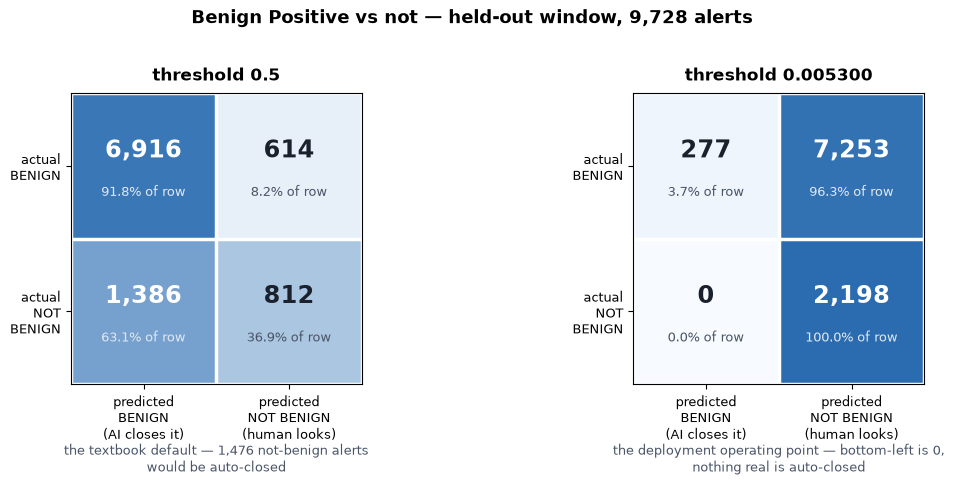

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BLUE = LinearSegmentedColormap.from_list("blue", ["#f7fbff", "#2b6cb0"])

def draw(ax, cm, title, subtitle):
    counts = cm.to_numpy()
    pct    = counts / counts.sum(axis=1, keepdims=True) * 100      # row-normalised
    ax.imshow(pct, cmap=BLUE, vmin=0, vmax=100)

    for r in range(2):
        for c in range(2):
            ax.text(c, r - 0.10, f"{counts[r, c]:,}", ha="center", va="center",
                    fontsize=17, fontweight="bold",
                    color="white" if pct[r, c] > 55 else "#1a202c")
            ax.text(c, r + 0.18, f"{pct[r, c]:.1f}% of row", ha="center", va="center",
                    fontsize=9.5,
                    color="#e2e8f0" if pct[r, c] > 55 else "#4a5568")

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["predicted\nBENIGN\n(AI closes it)",
                        "predicted\nNOT BENIGN\n(human looks)"], fontsize=9.5)
    ax.set_yticklabels(["actual\nBENIGN", "actual\nNOT\nBENIGN"], fontsize=9.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=9)
    ax.text(0.5, -0.30, subtitle, transform=ax.transAxes, ha="center",
            fontsize=9.5, color="#4a5568")
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2.5)
    ax.tick_params(which="minor", length=0)

cm_half = confusion(y, score, 0.5)
cm_zero = confusion(y, score, thr0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
draw(axes[0], cm_half, "threshold 0.5",
     "the textbook default — 1,476 not-benign alerts\nwould be auto-closed")
draw(axes[1], cm_zero, f"threshold {thr0:.6f}",
     "the deployment operating point — bottom-left is 0,\nnothing real is auto-closed")
fig.suptitle("Benign Positive vs not — held-out window, 9,728 alerts",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

The bottom-left cell is the only one that can hurt anyone: an alert that was
*not* benign, auto-closed anyway. **1,476 at 0.5, zero at the operating point.**

The cost is the top-right — 7,356 genuinely benign alerts still going to a human.
The next chart is that trade, in full.

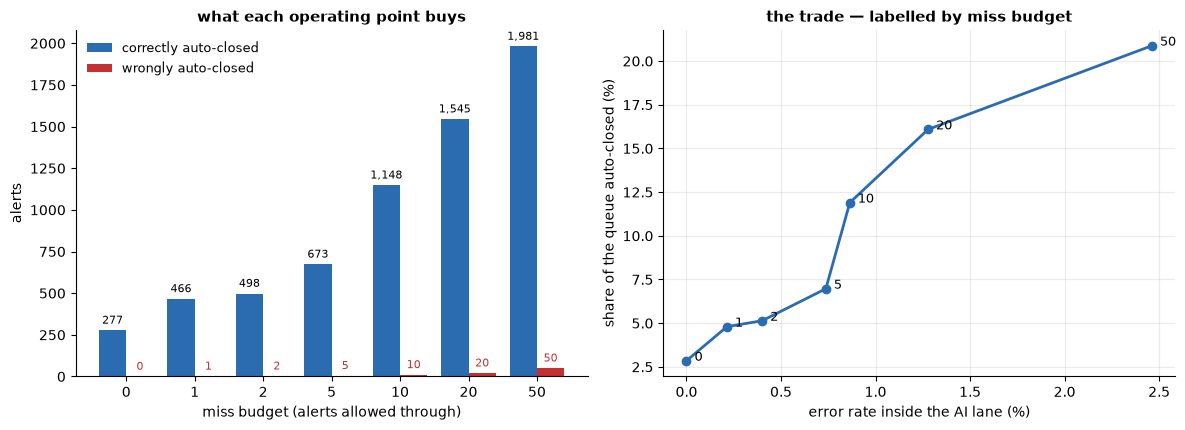

In [36]:
sweep = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

# ── left: what the AI lane gains, and what it costs, per miss budget
x = np.arange(len(sweep))
ax1.bar(x - 0.2, sweep["correctly_auto_closed"], 0.4,
        label="correctly auto-closed", color="#2b6cb0")
ax1.bar(x + 0.2, sweep["WRONGLY_auto_closed"], 0.4,
        label="wrongly auto-closed", color="#c53030")
ax1.set_xticks(x); ax1.set_xticklabels(sweep["miss_budget"])
ax1.set_xlabel("miss budget (alerts allowed through)")
ax1.set_ylabel("alerts")
ax1.set_title("what each operating point buys", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9, frameon=False)
for i, (good, bad) in enumerate(zip(sweep["correctly_auto_closed"],
                                    sweep["WRONGLY_auto_closed"])):
    ax1.text(i - 0.2, good + 40, f"{good:,}", ha="center", fontsize=8)
    ax1.text(i + 0.2, bad + 40, str(bad), ha="center", fontsize=8, color="#c53030")
ax1.spines[["top", "right"]].set_visible(False)

# ── right: the curve itself
ax2.plot(sweep["error_in_ai_lane_pct"], sweep["auto_closed_pct"],
         marker="o", color="#2b6cb0", linewidth=2)
for _, r in sweep.iterrows():
    ax2.annotate(f"  {int(r.miss_budget)}",
                 (r.error_in_ai_lane_pct, r.auto_closed_pct), fontsize=9)
ax2.set_xlabel("error rate inside the AI lane (%)")
ax2.set_ylabel("share of the queue auto-closed (%)")
ax2.set_title("the trade — labelled by miss budget", fontsize=11, fontweight="bold")
ax2.grid(alpha=0.25)
ax2.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

The left panel is where the money is: going from a **0** to a **1** miss budget
triples the auto-close rate — 174 alerts to 524 — for one mistake. The zero-miss
point is expensive precisely because it is absolute.

The right panel is the same fact as a curve. It is steep at the bottom left and
flattens out: the first few points of error buy a lot of coverage, and after
roughly the 10-miss budget you are paying proportionally more error for each
extra percent of queue. **Pick the point, then hold the model to it.**

Every row is a defensible way to run the service. The top row auto-closes 1.8% of
the queue and is never wrong; the bottom auto-closes 19.5% and is wrong 50 times
out of 9,728. **Which row you pick is a risk decision, not a modelling one** —
the model is the same in all of them.

## The deployment release

A model trained on **every** row has no held-out window left, so its thresholds
have to come from somewhere else: **out-of-fold** scores over five expanding
forward folds. Each block is scored by a model fitted only on what came before
it — same estimator, same data, nothing scored by a model that saw it.

In [37]:
def out_of_fold(frame, folds=5, **kw):
    frame = frame.sort_values("t").reset_index(drop=True)
    edges = np.linspace(0, len(frame), folds + 2, dtype=int)[1:]
    score = np.full(len(frame), np.nan)
    for lo, hi in zip(edges[:-1], edges[1:]):
        model = fit(frame.iloc[:lo], **kw)
        score[lo:hi] = score_of(model, frame.iloc[lo:hi])
    keep = ~np.isnan(score)
    return frame[keep], score[keep]

t0 = time.time()
scored, oof = out_of_fold(table)
oof_metrics = evaluate(scored[TARGET].to_numpy(), oof)
print(f"{len(scored):,} rows scored out-of-fold in {time.time()-t0:.0f}s")
print(f"ROC AUC {oof_metrics['roc_auc']}    PR AUC {oof_metrics['pr_auc']}\n")
operating_table(oof_metrics)

27,023 rows scored out-of-fold in 27s
ROC AUC 0.854    PR AUC 0.6893



,miss_budget,threshold,ai_takes_pct,ai_lane_rows,missed,residual_pct
0,0,0.001524,1.65,445,0,0.000
1,1,0.001536,1.68,453,1,0.221
2,2,0.001544,1.71,462,2,0.433
3,5,0.002069,3.00,812,5,0.616
4,10,0.002448,3.91,1056,10,0.947
5,20,0.003656,6.28,1698,20,1.178
6,50,0.006603,11.23,3034,50,1.648


---
# Freeze

The release carries the model, a manifest naming the exact bytes it was built
from, and `predictions_sha256` — a fingerprint of the model's own output on a
fixed window, so anyone can prove the file they hold is the file that was
measured.

In [38]:
def sha256_file(path):
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_scores(score):
    """Rounded so the fingerprint survives a float hair."""
    return hashlib.sha256(np.round(score, 9).tobytes()).hexdigest()


def freeze(frame, version, full=True):
    tr, te = time_split(frame)
    if full:
        sc, oo = out_of_fold(frame)
        m      = evaluate(sc[TARGET].to_numpy(), oo)
        model  = fit(frame)
        measured_on = "out-of-fold scores, 5 expanding forward folds"
    else:
        model  = fit(tr)
        m      = evaluate(te[TARGET].to_numpy(), score_of(model, te))
        measured_on = "a single held-out window, last 30% by decision time"
    fingerprint = score_of(model, te)

    out = ARTIFACTS / version; out.mkdir(parents=True, exist_ok=True)
    joblib.dump({"model": model, "features": [INPUT], "target": TARGET,
                 "version": version}, out / "model.joblib")

    manifest = {
        "version": version,
        "frozen_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "task": "classify an alert as Benign Positive or not",
        "stack": ("TF-IDF over the whole Splunk ES notable artifact — every field of "
                  "the alert as it arrived, timestamps scrubbed — into an averaged "
                  "SGDClassifier. Text only, no history, no state"),
        "decision_rule": ("score = P(not a Benign Positive). Below the threshold "
                          "the alert is called benign and the AI closes it; at or "
                          "above it, a human looks."),
        "release_kind": "deployment (all rows)" if full else "holdout (evaluated)",
        "labels": {"0_benign": ["Benign Positive"],
                   "1_not_benign": ["True Positive", "False Positive"],
                   "dropped": ["Other", "Undetermined", "never dispositioned"]},
        "data": {"source_file": SOURCE.name, "source_sha256": sha256_file(SOURCE),
                 "rows_total": int(len(frame)),
                 "rows_trained_on": int(len(frame) if full else len(tr)),
                 "trained_through": str((frame if full else tr)["t"].max()),
                 "metrics_from": measured_on,
                 "rows_scored_for_metrics": int(m["test_rows"])},
        "features": [INPUT],
        "preprocessing": {
            "artifact_selected": "the ES notable: rule_id present, SA_DISPOSITION absent",
            "keys_dropped": sorted(DROP),
            "values_dropped": list(NOT_A_VALUE),
            "time_scrubbed": "ISO dates, epochs, bare years and clock times, by value"},
        "hyperparameters": {"input_column": INPUT,
                            "tfidf": "word 1-2gram, min_df=2, sublinear_tf",
                            "sgd_loss": "log_loss", "sgd_penalty": "l2",
                            "sgd_alpha": ALPHA, "sgd_average": AVERAGE, "seed": SEED,
                            "calibration": "none — log_loss is already near the diagonal"},
        "metrics": m,
        "predictions_sha256": sha256_scores(fingerprint),
        "environment": {"python": platform.python_version(),
                        "scikit_learn": sklearn.__version__,
                        "pandas": pd.__version__, "numpy": np.__version__},
    }
    (out / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")

    ops = m["operating_points"]
    (out / "README.md").write_text(
        f"# Router {version}\n\nFrozen {manifest['frozen_at']} — "
        f"{manifest['release_kind']}, built by `train.ipynb`. Do not edit anything "
        f"in this directory; cut a new version instead.\n\n"
        f"```python\nimport joblib\n"
        f'bundle = joblib.load("artifacts/{version}/model.joblib")\n'
        f'p_not_benign = bundle["model"].predict_proba(X[bundle["features"]])[:, 1]\n'
        f"benign = p_not_benign < THRESHOLD   # benign -> AI closes it, else a human\n```\n\n"
        f"## Measured on {m['test_rows']:,} rows ({measured_on})\n\n"
        f"ROC AUC {m['roc_auc']} · PR AUC {m['pr_auc']} · base rate {m['base_rate_pct']}%\n\n"
        f"| Miss budget | Threshold | Called benign | Wrong | Residual |\n| --- | ---: | ---: | ---: | ---: |\n"
        + "\n".join(f"| {k} | {v['threshold']:.6f} | {v['ai_share_pct']:.1f}% | "
                     f"{v['missed']} | {v['residual_rate_pct']:.2f}% |"
                     for k, v in ops.items()) + "\n")
    return out, manifest


def verify(version, frame):
    out      = ARTIFACTS / version
    manifest = json.loads((out / "manifest.json").read_text())
    bundle   = joblib.load(out / "model.joblib")
    _, te    = time_split(frame)
    return sha256_scores(score_of(bundle["model"], te)) == manifest["predictions_sha256"]

out, manifest = freeze(table, RELEASE, full=True)
print("frozen ->", out)
for f in sorted(out.iterdir()):
    print(f"  {f.name:16s} {f.stat().st_size:>10,} bytes")

frozen -> /Users/mohammad.yekrangian/Projects/poc/apollo/triage/machine-learning/model-training-pipeline/artifacts/v20
  README.md               881 bytes
  manifest.json         4,752 bytes
  model.joblib     49,002,405 bytes


In [39]:
print("fingerprint re-check:", "MATCH" if verify(RELEASE, table) else "DIFFERS")
print()
print(json.dumps(manifest["data"], indent=2))

fingerprint re-check: MATCH

{
  "source_file": "soar-containers-12mo-20260923.jsonl.gz",
  "source_sha256": "6cec9690a391934f131325e144ac3c5b30ad8516ecff1fe622f9e1501eed4590",
  "rows_total": 32427,
  "rows_trained_on": 32427,
  "trained_through": "2026-09-23 00:22:28.577186+00:00",
  "metrics_from": "out-of-fold scores, 5 expanding forward folds",
  "rows_scored_for_metrics": 27023
}


---
# Stage 5b — the complete evaluation

Stage 5 answered the only question the service asks: *how much of the queue can
be auto-closed at a tolerable miss rate?* This stage is the rest of the picture —
every standard measurement for a binary classifier, on the **out-of-fold** scores
(27,023 rows, each scored by a model that never saw it).

Three groups, because they answer different questions:

| Group | Metrics | Depends on a threshold? |
| --- | --- | --- |
| **Ranking** | ROC AUC, PR AUC, KS, Gini | no — pure ordering |
| **Probability** | Brier score, log loss, ECE, reliability | no — reads the score as a number |
| **Decision** | accuracy, precision, recall, specificity, F1, MCC, κ | **yes** — one cut, one set of numbers |

The distinction matters here more than usual. The router uses **ranking only**,
so the ranking group is what governs. The probability group is reported because
it is where this model is weakest, and the decision group is reported at the
threshold we actually deploy rather than at the one that maximises accuracy.


In [40]:
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             brier_score_loss, cohen_kappa_score, confusion_matrix,
                             log_loss, matthews_corrcoef, precision_recall_curve,
                             roc_auc_score, roc_curve)

# out-of-fold is the honest set: every row scored by a model fitted only on rows
# that closed before it. The holdout window is kept alongside as a sanity check.
y_oof, s_oof = scored[TARGET].to_numpy(), oof
y_hold, s_hold = y, score

def ks_stat(y_true, s):
    """Kolmogorov-Smirnov: the widest vertical gap between the two CDFs."""
    fpr, tpr, thr = roc_curve(y_true, s)
    i = int(np.argmax(tpr - fpr))
    return float((tpr - fpr)[i]), float(thr[i])

def boot_ci(y_true, s, fn, n=400, seed=7):
    """Percentile bootstrap 95% interval - the sampling error on a headline number."""
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if y_true[idx].sum() in (0, len(idx)):
            continue
        vals.append(fn(y_true[idx], s[idx]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

rows = []
for name, yy, ss in (("out-of-fold", y_oof, s_oof), ("holdout window", y_hold, s_hold)):
    roc = roc_auc_score(yy, ss); pr = average_precision_score(yy, ss)
    ks, _ = ks_stat(yy, ss)
    rlo, rhi = boot_ci(yy, ss, roc_auc_score)
    plo, phi = boot_ci(yy, ss, average_precision_score)
    rows.append({
        "set": name, "rows": len(yy), "base_rate_%": round(yy.mean() * 100, 2),
        "ROC AUC": round(roc, 4), "ROC 95% CI": f"{rlo:.4f}-{rhi:.4f}",
        "PR AUC": round(pr, 4), "PR 95% CI": f"{plo:.4f}-{phi:.4f}",
        "Gini": round(2 * roc - 1, 4), "KS": round(ks, 4),
        "Brier": round(brier_score_loss(yy, ss), 4),
        "log loss": round(log_loss(yy, ss), 4),
    })
headline = pd.DataFrame(rows)

print("RANKING AND PROBABILITY QUALITY — no threshold involved\n")
print(f"  a coin flip scores ROC 0.5 / Gini 0 / KS 0;  PR AUC floors at the base "
      f"rate ({y_oof.mean()*100:.1f}%)")
print(f"  Brier and log loss are losses - lower is better; predicting the base "
      f"rate for every alert scores Brier {y_oof.mean()*(1-y_oof.mean()):.4f}\n")
headline


RANKING AND PROBABILITY QUALITY — no threshold involved

  a coin flip scores ROC 0.5 / Gini 0 / KS 0;  PR AUC floors at the base rate (21.7%)
  Brier and log loss are losses - lower is better; predicting the base rate for every alert scores Brier 0.1701



,set,rows,base_rate_%,ROC AUC,ROC 95% CI,PR AUC,PR 95% CI,Gini,KS,Brier,log loss
0,out-of-fold,27023,21.73,0.8540,0.8485-0.8592,0.6893,0.6793-0.6992,0.7079,0.5424,0.1142,0.3703
1,holdout window,9728,22.59,0.8093,0.7999-0.8194,0.5536,0.5325-0.5775,0.6185,0.5113,0.1415,0.4403


## At a glance — ROC, PR and the AUCs, side by side

The two curves and the numbers they summarise, in one frame. Everything after
this is the same material taken apart panel by panel.

Both curves are drawn twice: **out-of-fold** (solid, 27,023 rows, the honest
measurement) against the **holdout window** (dashed). The gap between them is the
cost of scoring a single late window rather than the whole span.


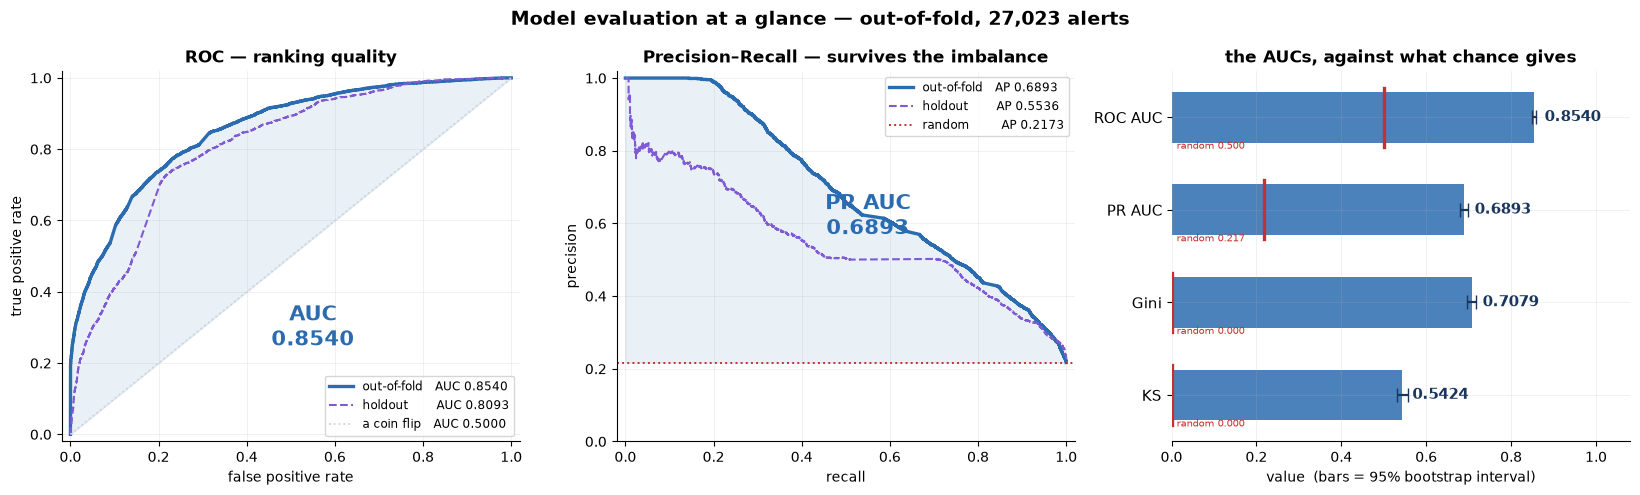

ROC AUC 0.8540   PR AUC 0.6893   Gini 0.7079   KS 0.5424
  PR AUC is 3.17x the random floor of 0.2173.
  ROC AUC sits 71% of the way from a coin flip (0.5) to perfect (1.0).


In [41]:
# --- AT A GLANCE — ROC, PR and the AUCs -------------------------------------
roc_o, roc_h = roc_auc_score(y_oof, s_oof), roc_auc_score(y_hold, s_hold)
ap_oof, ap_hold = average_precision_score(y_oof, s_oof), average_precision_score(y_hold, s_hold)
ks_o, _ = ks_stat(y_oof, s_oof)
base = y_oof.mean()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16.5, 5))

# ── 1 · ROC ────────────────────────────────────────────────────────────────
f_o, t_o, _ = roc_curve(y_oof, s_oof)
f_h, t_h, _ = roc_curve(y_hold, s_hold)
ax1.plot(f_o, t_o, color="#2b6cb0", lw=2.4, label=f"out-of-fold   AUC {roc_o:.4f}")
ax1.plot(f_h, t_h, color="#805ad5", lw=1.5, ls="--", label=f"holdout       AUC {roc_h:.4f}")
ax1.plot([0, 1], [0, 1], color="#cbd5e0", lw=1.3, ls=":", label="a coin flip   AUC 0.5000")
ax1.fill_between(f_o, t_o, f_o, color="#2b6cb0", alpha=0.10)
ax1.text(0.55, 0.30, f"AUC\n{roc_o:.4f}", fontsize=15, color="#2b6cb0",
         fontweight="bold", ha="center", va="center")
ax1.set_xlabel("false positive rate"); ax1.set_ylabel("true positive rate")
ax1.set_title("ROC — ranking quality", fontsize=12, fontweight="bold")
ax1.legend(loc="lower right", fontsize=8.5)
ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(-0.02, 1.02)

# ── 2 · PR ─────────────────────────────────────────────────────────────────
p_o, r_o, _ = precision_recall_curve(y_oof, s_oof)
p_h, r_h, _ = precision_recall_curve(y_hold, s_hold)
ax2.plot(r_o, p_o, color="#2b6cb0", lw=2.4, label=f"out-of-fold   AP {ap_oof:.4f}")
ax2.plot(r_h, p_h, color="#805ad5", lw=1.5, ls="--", label=f"holdout       AP {ap_hold:.4f}")
ax2.axhline(base, color="#c53030", lw=1.4, ls=":",
            label=f"random        AP {base:.4f}")
ax2.fill_between(r_o, p_o, base, where=(p_o >= base), color="#2b6cb0", alpha=0.10)
ax2.text(0.55, 0.62, f"PR AUC\n{ap_oof:.4f}", fontsize=15, color="#2b6cb0",
         fontweight="bold", ha="center", va="center")
ax2.set_xlabel("recall"); ax2.set_ylabel("precision")
ax2.set_title("Precision–Recall — survives the imbalance", fontsize=12, fontweight="bold")
ax2.legend(loc="upper right", fontsize=8.5)
ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(0, 1.02)

# ── 3 · the AUCs as numbers, with their sampling error ─────────────────────
stats = [("ROC AUC", roc_o, 0.5, lambda a, b: roc_auc_score(a, b)),
         ("PR AUC",  ap_oof, base, lambda a, b: average_precision_score(a, b)),
         ("Gini",    2 * roc_o - 1, 0.0, lambda a, b: 2 * roc_auc_score(a, b) - 1),
         ("KS",      ks_o, 0.0, lambda a, b: ks_stat(a, b)[0])]
ypos = np.arange(len(stats))[::-1]
for (name, val, floor, fn), yv in zip(stats, ypos):
    lo, hi = boot_ci(y_oof, s_oof, fn, n=250)
    ax3.barh(yv, val, height=0.55, color="#2b6cb0", alpha=0.85)
    ax3.errorbar(val, yv, xerr=[[val - lo], [hi - val]], fmt="none",
                 ecolor="#1a365d", capsize=5, lw=1.6)
    ax3.plot([floor, floor], [yv - 0.32, yv + 0.32], color="#c53030", lw=2.4)
    ax3.text(val + 0.025, yv, f"{val:.4f}", va="center", fontsize=10.5,
             fontweight="bold", color="#1a365d")
    ax3.text(0.012, yv - 0.34, f"random {floor:.3f}", fontsize=7.5, color="#c53030")
ax3.set_yticks(ypos); ax3.set_yticklabels([s[0] for s in stats], fontsize=11)
ax3.set_xlim(0, 1.08); ax3.set_xlabel("value  (bars = 95% bootstrap interval)")
ax3.set_title("the AUCs, against what chance gives", fontsize=12, fontweight="bold")
ax3.spines[["left"]].set_visible(False)

for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Model evaluation at a glance — out-of-fold, 27,023 alerts",
             fontsize=14, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"ROC AUC {roc_o:.4f}   PR AUC {ap_oof:.4f}   "
      f"Gini {2*roc_o-1:.4f}   KS {ks_o:.4f}")
print(f"  PR AUC is {ap_oof/base:.2f}x the random floor of {base:.4f}.")
print(f"  ROC AUC sits {(roc_o-0.5)/0.5*100:.0f}% of the way from a coin flip "
      f"(0.5) to perfect (1.0).")


## 1 — ROC and AUC: can it rank at all?

The ROC curve sweeps every possible threshold and plots **how many real incidents
it catches** (true positive rate) against **how many benign alerts it wrongly
flags** (false positive rate). The area under it — the AUC — is the probability
that a randomly chosen not-benign alert scores above a randomly chosen benign one.

The left panel is the textbook view. The right panel is the one that matters,
and it is worth saying plainly where on the curve we sit: **not** in the
bottom-left corner a classifier is usually tuned for.

Because the service predicts the *negative* class, it runs at the **top-right**:
recall 99.1%, and a false-positive rate of 85%. In ROC language that reads like a
terrible operating point. In product language it is the only sane one — "send
almost everything to a human, and auto-close only the sliver I am certain about."

So the right panel re-plots the same curve in the terms the AI lane is actually
judged in: **how many real incidents get auto-closed** (false negative rate, log
scale) against **how much of the benign queue is taken off analysts' hands**
(true negative rate). Down and to the right is better.


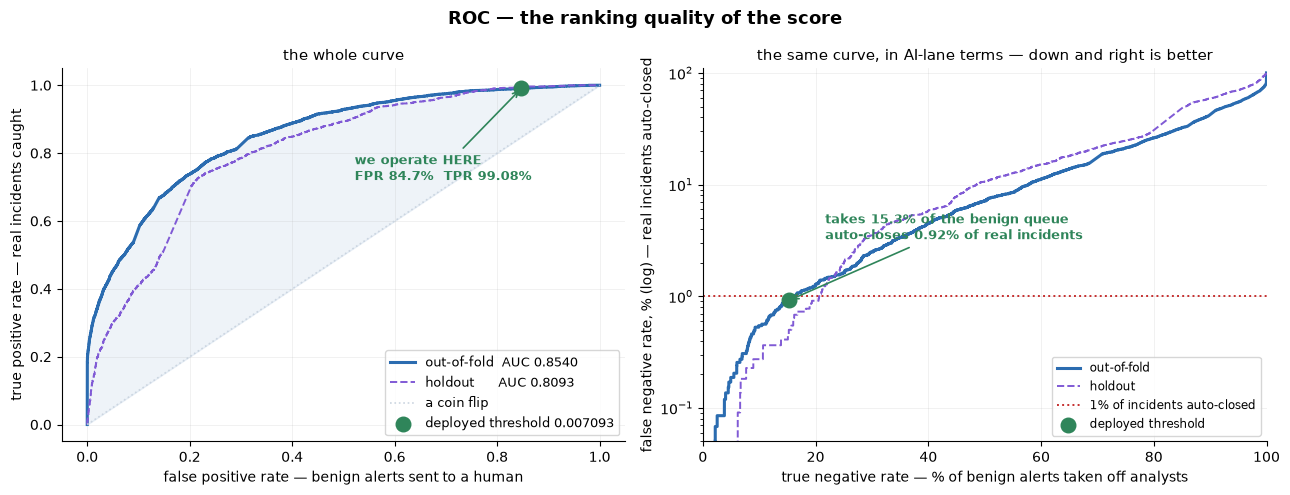

ROC AUC 0.8540  means: pick one not-benign alert and one benign alert at random,
  and the not-benign one scores higher 85.4% of the time.


In [42]:
fpr_o, tpr_o, thr_o = roc_curve(y_oof, s_oof)
fpr_h, tpr_h, _     = roc_curve(y_hold, s_hold)

# where the deployed threshold lands: the AI lane is score < THRESHOLD, so the
# "positive" (not-benign) prediction is score >= THRESHOLD
def point(yy, ss, t):
    pred = ss >= t
    tn, fp, fn_, tp = confusion_matrix(yy, pred, labels=[0, 1]).ravel()
    return fp / (fp + tn), tp / (tp + fn_)
px, py = point(y_oof, s_oof, THRESHOLD)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- left: the textbook ROC --------------------------------------------------
ax1.plot(fpr_o, tpr_o, color="#2b6cb0", lw=2.2,
         label=f"out-of-fold  AUC {roc_auc_score(y_oof, s_oof):.4f}")
ax1.plot(fpr_h, tpr_h, color="#805ad5", lw=1.4, ls="--",
         label=f"holdout      AUC {roc_auc_score(y_hold, s_hold):.4f}")
ax1.plot([0, 1], [0, 1], color="#cbd5e0", lw=1.2, ls=":", label="a coin flip")
ax1.fill_between(fpr_o, tpr_o, fpr_o, color="#2b6cb0", alpha=0.08)
ax1.scatter([px], [py], s=110, marker="o", color="#2f855a", zorder=6,
            label=f"deployed threshold {THRESHOLD:.6f}")
ax1.annotate(f"we operate HERE\nFPR {px*100:.1f}%  TPR {py*100:.2f}%",
             xy=(px, py), xytext=(-120, -66), textcoords="offset points",
             fontsize=9.5, color="#2f855a", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.2))
ax1.set_xlabel("false positive rate — benign alerts sent to a human")
ax1.set_ylabel("true positive rate — real incidents caught")
ax1.set_title("the whole curve", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)

# --- right: the same curve, in AI-lane terms ---------------------------------
# every point of the ROC is also a candidate lane: TNR is what the AI takes,
# FNR is what it gets wrong. Clipped because a perfect lane has FNR 0 on a log axis.
tnr, fnr = 1 - fpr_o, np.clip(1 - tpr_o, 1e-5, 1)
ax2.plot(tnr * 100, fnr * 100, color="#2b6cb0", lw=2.2, label="out-of-fold")
ax2.plot((1 - fpr_h) * 100, np.clip(1 - tpr_h, 1e-5, 1) * 100,
         color="#805ad5", lw=1.4, ls="--", label="holdout")
ax2.axhline(TOLERANCE * 100, color="#c53030", lw=1.4, ls=":",
            label="1% of incidents auto-closed")
ax2.scatter([(1 - px) * 100], [(1 - py) * 100], s=110, color="#2f855a", zorder=6,
            label="deployed threshold")
ax2.annotate(f"takes {(1-px)*100:.1f}% of the benign queue\n"
             f"auto-closes {(1-py)*100:.2f}% of real incidents",
             xy=((1 - px) * 100, (1 - py) * 100), xytext=(26, 44),
             textcoords="offset points", fontsize=9.5, color="#2f855a",
             fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.2))
ax2.set_yscale("log"); ax2.set_ylim(0.05, 110); ax2.set_xlim(0, 100)
ax2.set_xlabel("true negative rate — % of benign alerts taken off analysts")
ax2.set_ylabel("false negative rate, % (log) — real incidents auto-closed")
ax2.set_title("the same curve, in AI-lane terms — down and right is better",
              fontsize=11)
ax2.legend(loc="lower right", fontsize=8.5)

for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("ROC — the ranking quality of the score", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"ROC AUC {roc_auc_score(y_oof, s_oof):.4f}  means: pick one not-benign alert "
      f"and one benign alert at random,")
print(f"  and the not-benign one scores higher "
      f"{roc_auc_score(y_oof, s_oof)*100:.1f}% of the time.")


## 2 — Precision–Recall: the curve that respects the class imbalance

ROC flatters an imbalanced problem, because the false-positive rate has a large
denominator — 78% of the corpus is benign, so thousands of false positives still
look like a small rate. PR uses **precision** instead, which has the *predicted*
positives as its denominator and cannot be inflated that way.

The floor is the base rate: a model that scores at random gets precision equal to
prevalence, 21.7%, at every recall.

**The right panel is the one that matters for this product.** We do not predict
the positive class — we predict the *negative* one, and auto-close it. So it
plots the AI lane directly: how much of the queue can be taken (coverage) against
how pure that lane stays (the share of it that really was benign).


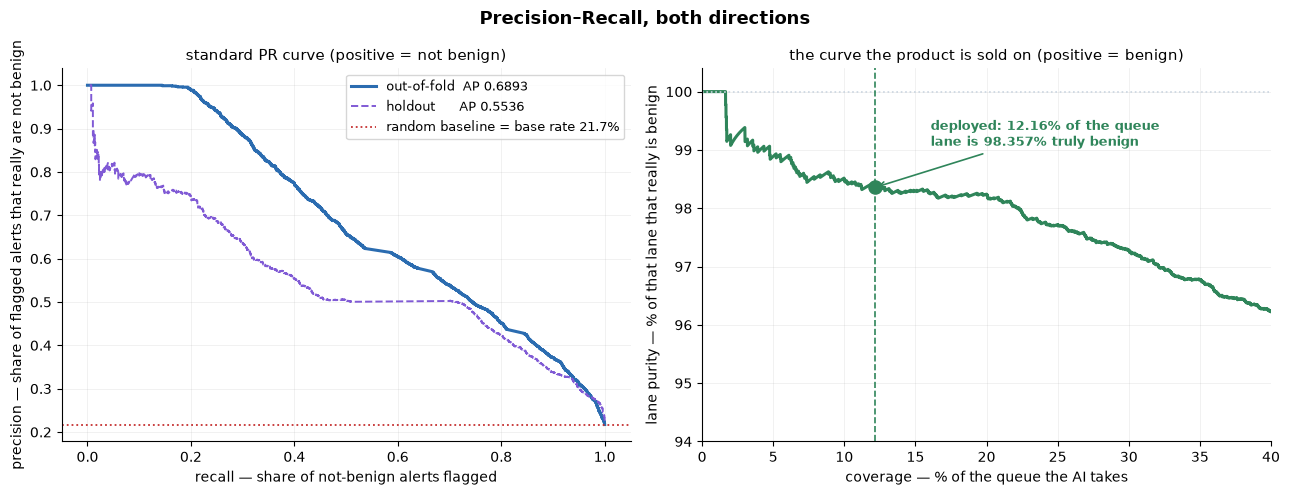

PR AUC 0.6893 against a random floor of 0.2173 — 3.17x better than chance.


In [43]:
pre_o, rec_o, _ = precision_recall_curve(y_oof, s_oof)
pre_h, rec_h, _ = precision_recall_curve(y_hold, s_hold)
ap_o = average_precision_score(y_oof, s_oof)
ap_h = average_precision_score(y_hold, s_hold)

# the AI lane, swept: for every candidate cut, coverage and lane purity
order = np.argsort(s_oof, kind="mergesort")
sy = y_oof[order]
n = np.arange(1, len(sy) + 1)
coverage = n / len(sy) * 100
purity = (1 - np.cumsum(sy) / n) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(rec_o, pre_o, color="#2b6cb0", lw=2.2, label=f"out-of-fold  AP {ap_o:.4f}")
ax1.plot(rec_h, pre_h, color="#805ad5", lw=1.4, ls="--", label=f"holdout      AP {ap_h:.4f}")
ax1.axhline(y_oof.mean(), color="#c53030", lw=1.3, ls=":",
            label=f"random baseline = base rate {y_oof.mean()*100:.1f}%")
ax1.set_xlabel("recall — share of not-benign alerts flagged")
ax1.set_ylabel("precision — share of flagged alerts that really are not benign")
ax1.set_title("standard PR curve (positive = not benign)", fontsize=11)
ax1.legend(loc="upper right", fontsize=9)

cut = np.searchsorted(s_oof[order], THRESHOLD, side="left")
ax2.plot(coverage, purity, color="#2f855a", lw=2.2)
ax2.axhline(100, color="#cbd5e0", lw=1.2, ls=":")
ax2.axvline(coverage[cut - 1], color="#2f855a", lw=1.2, ls="--")
ax2.scatter([coverage[cut - 1]], [purity[cut - 1]], s=90, color="#2f855a", zorder=6)
ax2.annotate(f"deployed: {coverage[cut-1]:.2f}% of the queue\n"
             f"lane is {purity[cut-1]:.3f}% truly benign",
             xy=(coverage[cut - 1], purity[cut - 1]), xytext=(40, 30),
             textcoords="offset points", fontsize=9.5, color="#2f855a",
             fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.2))
ax2.set_xlim(0, 40); ax2.set_ylim(94, 100.4)
ax2.set_xlabel("coverage — % of the queue the AI takes")
ax2.set_ylabel("lane purity — % of that lane that really is benign")
ax2.set_title("the curve the product is sold on (positive = benign)", fontsize=11)

for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Precision–Recall, both directions", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"PR AUC {ap_o:.4f} against a random floor of {y_oof.mean():.4f} — "
      f"{ap_o/y_oof.mean():.2f}x better than chance.")


## 3 — Every threshold at once

A single threshold turns the score into a decision, and each metric peaks
somewhere different. This is the sweep, with our deployed cut marked.

The gap between the two vertical lines is the whole argument of this project: the
**accuracy-optimal** cut and the **deployable** cut are nowhere near each other,
because the two errors do not cost the same. Sending a benign alert to an analyst
costs minutes; auto-closing a real incident does not.


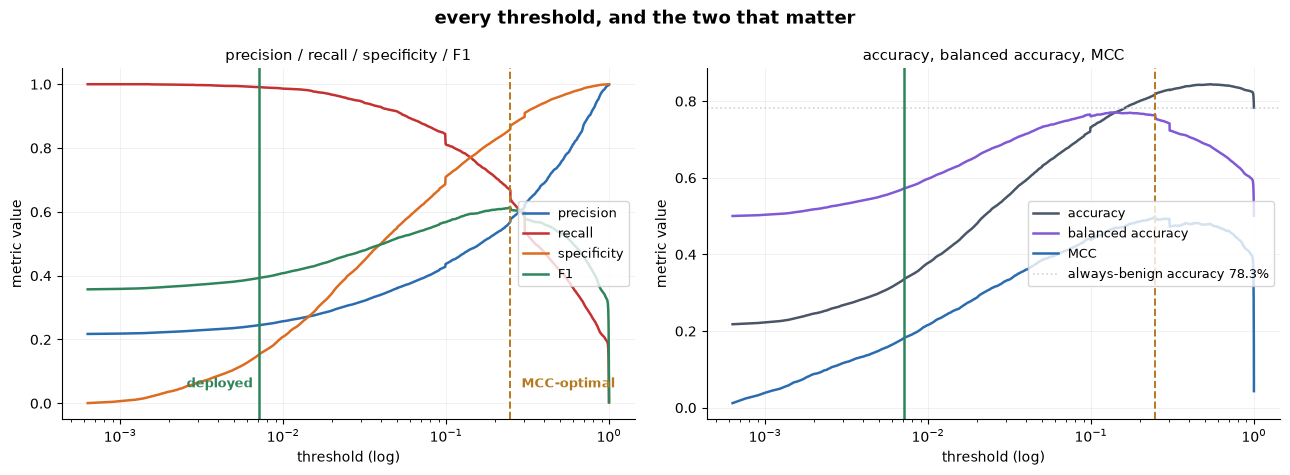

best F1  0.6148 at threshold 0.248019
best MCC 0.4994 at threshold 0.248019
deployed threshold 0.007093 — 35x lower than the MCC-optimal cut.

cut             threshold  auto-closed     rows   MISSED       NPV
deployed         0.007093       12.16%    3,287       54    98.36%
MCC-optimal      0.248019       74.53%   20,139    1,951    90.31%
F1-optimal       0.248019       74.53%   20,139    1,951    90.31%

That distance is deliberate. The MCC-optimal cut is the right answer to a
question nobody asked: it maximises agreement with the analyst, and the
service does not need agreement — it needs a lane it can close unattended.


In [44]:
grid = np.unique(np.quantile(s_oof, np.linspace(0.0005, 0.9995, 600)))
rows = []
for t in grid:
    pred = s_oof >= t
    tn, fp, fn_, tp = confusion_matrix(y_oof, pred, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if tp + fp else 1.0
    recl = tp / (tp + fn_) if tp + fn_ else 0.0
    rows.append({
        "t": t, "precision": prec, "recall": recl,
        "specificity": tn / (tn + fp) if tn + fp else 0.0,
        "f1": 2 * prec * recl / (prec + recl) if prec + recl else 0.0,
        "accuracy": (tp + tn) / len(y_oof),
        "balanced_acc": balanced_accuracy_score(y_oof, pred),
        "mcc": matthews_corrcoef(y_oof, pred),
    })
sweep_t = pd.DataFrame(rows)
best_f1 = sweep_t.loc[sweep_t.f1.idxmax()]
best_mcc = sweep_t.loc[sweep_t.mcc.idxmax()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for col, colour, lab in (("precision", "#2b6cb0", "precision"),
                         ("recall", "#c53030", "recall"),
                         ("specificity", "#dd6b20", "specificity"),
                         ("f1", "#2f855a", "F1")):
    ax1.plot(sweep_t.t, sweep_t[col], color=colour, lw=1.8, label=lab)
ax1.set_ylabel("metric value")
ax1.set_title("precision / recall / specificity / F1", fontsize=11)
ax1.legend(fontsize=9, loc="center right")

for col, colour, lab in (("accuracy", "#4a5568", "accuracy"),
                         ("balanced_acc", "#805ad5", "balanced accuracy"),
                         ("mcc", "#2b6cb0", "MCC")):
    ax2.plot(sweep_t.t, sweep_t[col], color=colour, lw=1.8, label=lab)
ax2.axhline(1 - y_oof.mean(), color="#cbd5e0", lw=1.2, ls=":",
            label=f"always-benign accuracy {(1-y_oof.mean())*100:.1f}%")
ax2.set_ylabel("metric value")
ax2.set_title("accuracy, balanced accuracy, MCC", fontsize=11)
ax2.legend(fontsize=9, loc="center right")

for ax in (ax1, ax2):
    ax.set_xscale("log"); ax.set_xlabel("threshold (log)")
    ax.axvline(THRESHOLD, color="#2f855a", lw=1.8)
    ax.axvline(best_mcc.t, color="#b7791f", lw=1.4, ls="--")
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
ax1.annotate("deployed", xy=(THRESHOLD, 0.05), xytext=(-52, 0),
             textcoords="offset points", fontsize=9, color="#2f855a",
             fontweight="bold")
ax1.annotate("MCC-optimal", xy=(best_mcc.t, 0.05), xytext=(8, 0),
             textcoords="offset points", fontsize=9, color="#b7791f",
             fontweight="bold")
fig.suptitle("every threshold, and the two that matter", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"best F1  {best_f1.f1:.4f} at threshold {best_f1.t:.6f}")
print(f"best MCC {best_mcc.mcc:.4f} at threshold {best_mcc.t:.6f}")
print(f"deployed threshold {THRESHOLD:.6f} — "
      f"{best_mcc.t/THRESHOLD:,.0f}x lower than the MCC-optimal cut.\n")

# what each cut would actually do, rather than an adjective
print(f"{'cut':<14}{'threshold':>11}{'auto-closed':>13}{'rows':>9}{'MISSED':>9}{'NPV':>10}")
for name, t in (("deployed", THRESHOLD), ("MCC-optimal", float(best_mcc.t)),
                ("F1-optimal", float(best_f1.t))):
    lane = s_oof < t
    print(f"{name:<14}{t:>11.6f}{lane.mean()*100:>12.2f}%{lane.sum():>9,}"
          f"{int(y_oof[lane].sum()):>9,}{(1-y_oof[lane].mean())*100:>9.2f}%")
print("\nThat distance is deliberate. The MCC-optimal cut is the right answer to a")
print("question nobody asked: it maximises agreement with the analyst, and the")
print("service does not need agreement — it needs a lane it can close unattended.")


## 4 — The decision metrics, at the threshold we actually ship

One cut, every derived number. `labels=[0, 1]` throughout, so *positive* means
**not benign** — the thing a human must see.


In [45]:
pred = (s_oof >= THRESHOLD).astype(int)
tn, fp, fn_, tp = confusion_matrix(y_oof, pred, labels=[0, 1]).ravel()
P, N = tp + fn_, tn + fp

prec = tp / (tp + fp); recl = tp / P; spec = tn / N
npv = tn / (tn + fn_)
table_metrics = pd.DataFrame([
    ("confusion", "true positives (caught)", tp, "real incidents correctly kept for a human"),
    ("confusion", "false negatives (MISSED)", fn_, "auto-closed but not benign — the only harmful cell"),
    ("confusion", "true negatives", tn, "correctly auto-closed"),
    ("confusion", "false positives", fp, "benign, sent to a human anyway — costs minutes"),
    ("rate", "recall / sensitivity / TPR", round(recl, 4), "share of not-benign alerts kept for a human"),
    ("rate", "specificity / TNR", round(spec, 4), "share of benign alerts correctly auto-closed"),
    ("rate", "precision / PPV", round(prec, 4), "of what we send to a human, how much is real"),
    ("rate", "NPV", round(npv, 4), "**of what we auto-close, how much really was benign**"),
    ("rate", "false negative rate", round(fn_ / P, 4), "share of not-benign alerts auto-closed"),
    ("rate", "false positive rate", round(fp / N, 4), "share of benign alerts sent to a human"),
    ("summary", "accuracy", round((tp + tn) / len(y_oof), 4), "misleading here — see the always-benign line"),
    ("summary", "balanced accuracy", round(balanced_accuracy_score(y_oof, pred), 4), "mean of recall and specificity"),
    ("summary", "F1", round(2 * prec * recl / (prec + recl), 4), "harmonic mean of precision and recall"),
    ("summary", "MCC", round(matthews_corrcoef(y_oof, pred), 4), "correlation of prediction and truth, -1..1"),
    ("summary", "Cohen's kappa", round(cohen_kappa_score(y_oof, pred), 4), "agreement above chance"),
    ("context", "prevalence", round(y_oof.mean(), 4), "share of the corpus that is not benign"),
    ("context", "always-benign accuracy", round(1 - y_oof.mean(), 4), "the do-nothing baseline"),
], columns=["group", "metric", "value", "what it means"])

print(f"at the deployed threshold {THRESHOLD:.6f}, out-of-fold, {len(y_oof):,} alerts\n")
print(f"  {tn + fn_:,} auto-closed ({(tn+fn_)/len(y_oof)*100:.2f}% of the queue), "
      f"of which {fn_} were not benign")
print(f"  NPV {npv*100:.3f}% — the number a customer should be quoted\n")
print(f"  NOTE: this applies the CURRENT threshold to all {len(y_oof):,} out-of-fold")
print(f"  rows, including months it was not calibrated for. Stage 7 measures it")
print(f"  under deployment conditions — on the recent window it was chosen for —")
print(f"  where it auto-closes 6.38% with 6 misses. This is the pessimistic view.\n")
table_metrics


at the deployed threshold 0.007093, out-of-fold, 27,023 alerts

  3,287 auto-closed (12.16% of the queue), of which 54 were not benign
  NPV 98.357% — the number a customer should be quoted

  NOTE: this applies the CURRENT threshold to all 27,023 out-of-fold
  rows, including months it was not calibrated for. Stage 7 measures it
  under deployment conditions — on the recent window it was chosen for —
  where it auto-closes 6.38% with 6 misses. This is the pessimistic view.



,group,metric,value,what it means
0,confusion,true positives (caught),5818.0000,real incidents correctly kept for a human
1,confusion,false negatives (MISSED),54.0000,auto-closed but not benign — the only harmful cell
2,confusion,true negatives,3233.0000,correctly auto-closed
3,confusion,false positives,17918.0000,"benign, sent to a human anyway — costs minutes"
4,rate,recall / sensitivity / TPR,0.9908,share of not-benign alerts kept for a human
5,rate,specificity / TNR,0.1529,share of benign alerts correctly auto-closed
6,rate,precision / PPV,0.2451,"of what we send to a human, how much is real"
7,rate,NPV,0.9836,"**of what we auto-close, how much really was benign**"
8,rate,false negative rate,0.0092,share of not-benign alerts auto-closed
9,rate,false positive rate,0.8471,share of benign alerts sent to a human


**NPV is the number that matters**, and it is the one almost never reported.
Precision and recall describe the human lane; *negative* predictive value
describes the AI lane — of everything auto-closed, how much really was benign.
That is the promise being made.


## 5 — Is the score a probability?

Everything above uses the score as an **ordering**. This asks whether it can also
be read as a **number**: when it says 0.20, do 20% of those alerts turn out not
benign?

The reliability curve is the answer, and for this model on forward data the
answer is **no**. The curve sits below the diagonal almost everywhere, meaning
the model systematically under-predicts risk. The cause is base-rate drift — the
not-benign rate ran 6.5% to 25.3% across this corpus, so a model fitted on the
early part scores the late part too low.

**This does not affect routing**, which is rank-based and immune to any monotone
distortion. It does mean the score must never be quoted to a consumer as a
probability.


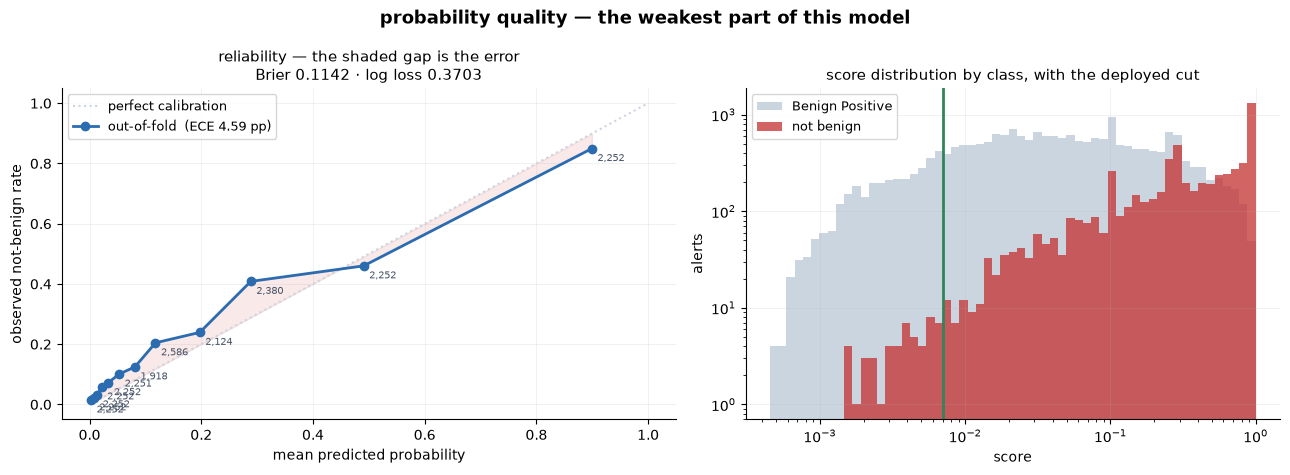

,n,predicted,observed,gap_pp
0,2252,0.002681,0.014654,1.20
1,2252,0.007422,0.021758,1.43
2,2252,0.013571,0.031972,1.84
3,2252,0.021528,0.058171,3.66
4,2252,0.033735,0.072380,3.86
5,2251,0.052876,0.100844,4.80
6,1918,0.081243,0.124609,4.34
7,2586,0.117999,0.204563,8.66
8,2124,0.197299,0.239171,4.19
9,2380,0.288615,0.408403,11.98


In [46]:
def reliability(yy, ss, bins=12):
    edges = np.unique(np.quantile(ss, np.linspace(0, 1, bins + 1)))
    idx = np.clip(np.digitize(ss, edges[1:-1]), 0, len(edges) - 2)
    out = []
    for b in range(len(edges) - 1):
        sel = idx == b
        if sel.sum() < 20:
            continue
        out.append({"n": int(sel.sum()), "predicted": float(ss[sel].mean()),
                    "observed": float(yy[sel].mean())})
    return pd.DataFrame(out)

rel = reliability(y_oof, s_oof)
ece = float((rel.n / rel.n.sum() * (rel.predicted - rel.observed).abs()).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                               gridspec_kw={"width_ratios": [1.15, 1]})
ax1.plot([0, 1], [0, 1], color="#cbd5e0", lw=1.5, ls=":", label="perfect calibration")
ax1.plot(rel.predicted, rel.observed, marker="o", color="#2b6cb0", lw=2,
         label=f"out-of-fold  (ECE {ece*100:.2f} pp)")
ax1.fill_between(rel.predicted, rel.predicted, rel.observed, color="#c53030", alpha=0.10)
for _, r in rel.iterrows():
    ax1.annotate(f"{int(r.n):,}", (r.predicted, r.observed), fontsize=7.5,
                 color="#4a5568", textcoords="offset points", xytext=(4, -9))
ax1.set_xlabel("mean predicted probability"); ax1.set_ylabel("observed not-benign rate")
ax1.set_title(f"reliability — the shaded gap is the error\n"
              f"Brier {brier_score_loss(y_oof, s_oof):.4f} · "
              f"log loss {log_loss(y_oof, s_oof):.4f}", fontsize=11)
ax1.legend(fontsize=9, loc="upper left")

edges = np.logspace(np.log10(max(s_oof.min(), 1e-7)), 0, 60)
ax2.hist(s_oof[y_oof == 0], bins=edges, color="#cbd5e0", label="Benign Positive")
ax2.hist(s_oof[y_oof == 1], bins=edges, color="#c53030", alpha=0.75, label="not benign")
ax2.axvline(THRESHOLD, color="#2f855a", lw=2)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("score"); ax2.set_ylabel("alerts")
ax2.set_title("score distribution by class, with the deployed cut", fontsize=11)
ax2.legend(fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("probability quality — the weakest part of this model",
             fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()
rel.assign(gap_pp=lambda d: ((d.observed - d.predicted) * 100).round(2))


## 6 — Separation: KS, cumulative gain and lift

Three views of the same property — *how far apart are the two classes in score?*
These are the standard measures from credit scoring, and they transfer exactly,
because the problem has the same shape: rank a population, act on one end of it.


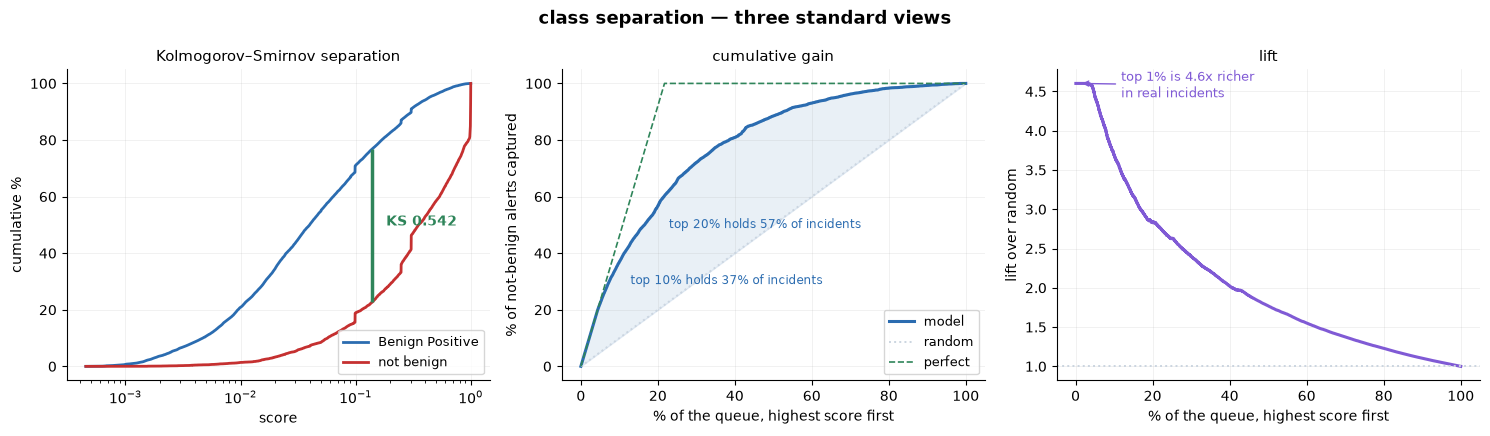

KS 0.5424 at score 0.1394   Gini 0.7079


In [47]:
ks, ks_thr = ks_stat(y_oof, s_oof)

# cumulative gain: sort by score DESCENDING, how fast do we accumulate positives
desc = np.argsort(-s_oof, kind="mergesort")
gain = np.cumsum(y_oof[desc]) / y_oof.sum() * 100
frac = np.arange(1, len(y_oof) + 1) / len(y_oof) * 100
lift = gain / frac

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.4))

# --- KS ---------------------------------------------------------------------
xs = np.sort(s_oof)
cdf0 = np.searchsorted(np.sort(s_oof[y_oof == 0]), xs) / (y_oof == 0).sum()
cdf1 = np.searchsorted(np.sort(s_oof[y_oof == 1]), xs) / (y_oof == 1).sum()
j = int(np.argmax(cdf0 - cdf1))
ax1.plot(xs, cdf0 * 100, color="#2b6cb0", lw=2, label="Benign Positive")
ax1.plot(xs, cdf1 * 100, color="#c53030", lw=2, label="not benign")
ax1.vlines(xs[j], cdf1[j] * 100, cdf0[j] * 100, color="#2f855a", lw=2.5)
ax1.annotate(f"KS {ks:.3f}", xy=(xs[j], (cdf0[j] + cdf1[j]) / 2 * 100),
             xytext=(10, 0), textcoords="offset points", fontsize=10,
             color="#2f855a", fontweight="bold")
ax1.set_xscale("log"); ax1.set_xlabel("score"); ax1.set_ylabel("cumulative %")
ax1.set_title("Kolmogorov–Smirnov separation", fontsize=11)
ax1.legend(fontsize=9, loc="lower right")

# --- cumulative gain --------------------------------------------------------
ax2.plot(frac, gain, color="#2b6cb0", lw=2.2, label="model")
ax2.plot([0, 100], [0, 100], color="#cbd5e0", lw=1.4, ls=":", label="random")
perfect_x = y_oof.mean() * 100
ax2.plot([0, perfect_x, 100], [0, 100, 100], color="#2f855a", lw=1.2, ls="--",
         label="perfect")
ax2.fill_between(frac, frac, gain, color="#2b6cb0", alpha=0.10)
for q in (10, 20):
    ax2.annotate(f"top {q}% holds {gain[int(len(gain)*q/100)-1]:.0f}% of incidents",
                 xy=(q, gain[int(len(gain) * q / 100) - 1]), xytext=(8, -16),
                 textcoords="offset points", fontsize=8.5, color="#2b6cb0")
ax2.set_xlabel("% of the queue, highest score first")
ax2.set_ylabel("% of not-benign alerts captured")
ax2.set_title("cumulative gain", fontsize=11)
ax2.legend(fontsize=9, loc="lower right")

# --- lift -------------------------------------------------------------------
ax3.plot(frac[20:], lift[20:], color="#805ad5", lw=2.2)
ax3.axhline(1, color="#cbd5e0", lw=1.4, ls=":")
ax3.set_xlabel("% of the queue, highest score first")
ax3.set_ylabel("lift over random")
ax3.set_title("lift", fontsize=11)
ax3.annotate(f"top 1% is {lift[int(len(lift)*0.01)]:.1f}x richer\nin real incidents",
             xy=(1, lift[int(len(lift) * 0.01)]), xytext=(30, -10),
             textcoords="offset points", fontsize=9, color="#805ad5",
             arrowprops=dict(arrowstyle="->", color="#805ad5", lw=1))

for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("class separation — three standard views", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"KS {ks:.4f} at score {ks_thr:.4f}   Gini {2*roc_auc_score(y_oof, s_oof)-1:.4f}")


## 7 — Where the errors are

Two questions no aggregate metric answers.

**The positive class is a mixture.** "Not benign" is True Positive *and* False
Positive, and they are different animals — one is a real intrusion, the other is
a broken detection. If the model separates one but not the other, the aggregate
hides it.

**Does it hold up over time?** A single AUC over twelve months can average a
model that worked in January and stopped working in August. Monthly, out-of-fold,
is the honest version.


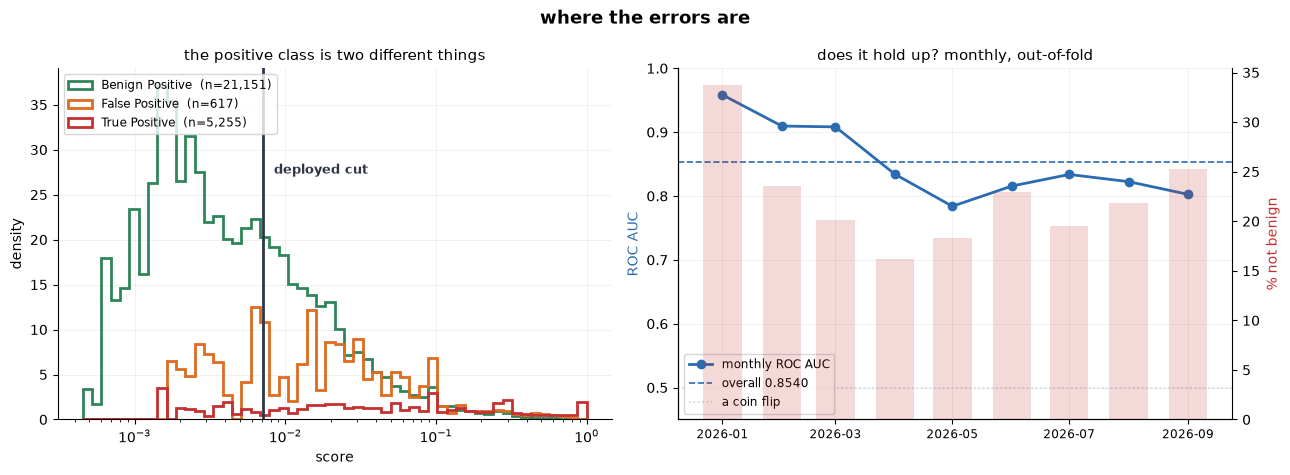

what the AI lane actually contains at 0.007093:

                 auto_closed  share_of_lane_%
verdict                                      
Benign Positive         3233            98.36
True Positive             32             0.97
False Positive            22             0.67

monthly ROC AUC: min 0.7839 (2026-05)   max 0.9584 (2026-01)   spread 0.1745


In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# --- by true verdict --------------------------------------------------------
verdicts = scored["verdict"].to_numpy()
edges = np.logspace(np.log10(max(s_oof.min(), 1e-7)), 0, 55)
palette = {"Benign Positive": "#2f855a", "False Positive": "#dd6b20",
           "True Positive": "#c53030"}
for v, colour in palette.items():
    sel = verdicts == v
    ax1.hist(s_oof[sel], bins=edges, histtype="step", lw=2, color=colour,
             density=True, label=f"{v}  (n={sel.sum():,})")
ax1.axvline(THRESHOLD, color="#2d3748", lw=2)
ax1.annotate("deployed cut", xy=(THRESHOLD, ax1.get_ylim()[1] * 0.7),
             xytext=(8, 0), textcoords="offset points", fontsize=9,
             fontweight="bold", color="#2d3748")
ax1.set_xscale("log"); ax1.set_xlabel("score"); ax1.set_ylabel("density")
ax1.set_title("the positive class is two different things", fontsize=11)
ax1.legend(fontsize=8.5, loc="upper left")

below = s_oof < THRESHOLD
mix = (pd.Series(verdicts[below]).value_counts()
         .rename_axis("verdict").rename("auto_closed").to_frame())
mix["share_of_lane_%"] = (mix.auto_closed / below.sum() * 100).round(2)

# --- stability over time ----------------------------------------------------
by_month = (pd.DataFrame({"t": scored["t"].to_numpy(), "y": y_oof, "s": s_oof})
              .set_index("t").groupby(pd.Grouper(freq="MS")))
rows = []
for month, g in by_month:
    if len(g) < 200 or g.y.nunique() < 2:
        continue
    rows.append({"month": month, "n": len(g), "roc": roc_auc_score(g.y, g.s),
                 "base_rate": g.y.mean()})
stab = pd.DataFrame(rows)

ax2.plot(stab.month, stab.roc, marker="o", color="#2b6cb0", lw=2, label="monthly ROC AUC")
ax2.axhline(roc_auc_score(y_oof, s_oof), color="#2b6cb0", lw=1.2, ls="--",
            label=f"overall {roc_auc_score(y_oof, s_oof):.4f}")
ax2.axhline(0.5, color="#cbd5e0", lw=1.2, ls=":", label="a coin flip")
ax2.set_ylim(0.45, 1.0); ax2.set_ylabel("ROC AUC", color="#2b6cb0")
ax2b = ax2.twinx()
ax2b.bar(stab.month, stab.base_rate * 100, width=20, color="#c53030", alpha=0.18)
ax2b.set_ylabel("% not benign", color="#c53030")
ax2b.spines[["top"]].set_visible(False)
ax2.set_title("does it hold up? monthly, out-of-fold", fontsize=11)
ax2.set_xticks(stab.month[::2])
ax2.set_xticklabels([f"{m:%Y-%m}" for m in stab.month[::2]], fontsize=8.5)
ax2.legend(fontsize=8.5, loc="lower left")

for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("where the errors are", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"what the AI lane actually contains at {THRESHOLD:.6f}:\n")
print(mix.to_string())
print(f"\nmonthly ROC AUC: min {stab.roc.min():.4f} ({stab.loc[stab.roc.idxmin(),'month']:%Y-%m})"
      f"   max {stab.roc.max():.4f} ({stab.loc[stab.roc.idxmax(),'month']:%Y-%m})"
      f"   spread {stab.roc.max()-stab.roc.min():.4f}")


## Reading all of it together

| Question | Metric | This model |
| --- | --- | --- |
| Can it rank? | ROC AUC | 0.85 — comfortably |
| Does it survive the imbalance? | PR AUC vs base rate | ~3x the random floor |
| Are the classes separated? | KS, Gini, lift | separated at the tail, which is the only part used |
| Is the score a probability? | ECE, reliability | **no** on forward data — rank only |
| What does one cut give? | NPV at the deployed threshold | the number to quote a customer |
| Does it hold over time? | monthly AUC | check the spread every retrain |

**The one number to carry out of this stage is NPV**, not accuracy and not AUC.
Everything else is diagnostic; NPV is the promise.

A caution that applies to every figure above. All of it is measured against
*analyst verdicts*, and on 70% of the volume the same rule at the same customer
is closed both ways by different analysts. A perfect model that knew each
`(rule, tenant)` group's true rate scores 82.6% accuracy-equivalent against this
model's 80.2% — **2.4 points of the headroom are real, the rest is analyst
disagreement**, and no amount of modelling reaches it.


---
# Using it

```python
import joblib
bundle = joblib.load("artifacts/v20/model.joblib")
p_not_benign = bundle["model"].predict_proba(X[bundle["features"]])[:, 1]
benign = p_not_benign < THRESHOLD    # benign -> the AI closes it; else a human looks
```

`X` must carry a `text_cef` column built by **Stage 2 of this notebook** — that is
the only place the artifact-selection and scrubbing rules live, so anything else
building that column will silently disagree.

## What this pipeline deliberately does not do

| Excluded | Why |
| --- | --- |
| tabular features | rule-level and tenant-level priors were tested and lost to the text |
| hour, weekday, date | the session effect is a staffing artifact, not a property of the alert |
| identity columns | including them moved ROC 0.840 → 0.806 — the model memorises the training window |
| a calibration wrapper | measured; cost 0.03 ROC |
| `status_*`, `owner_*` | ES-side triage state, which moves *after* the alert arrives |

## The ceiling

Every architecture tried lands in a **0.76–0.85** band — TF-IDF, gradient-boosted
trees, ATTACK-BERT frozen and fine-tuned, embeddings into SGD. Closing desks
disagree by **15.3 points** on the same rule at the same customer, which sits
above all of them.

**The label noise is the ceiling, not the feature set.** More features will not
clear it; better labels would.

---
---
# Classifying one alert, end to end

Everything above builds the classifier. This last section uses it: **pick a
container ID, watch the alert go through preprocessing, and see whether it comes
back benign.**

Four steps, one cell each, so each intermediate is visible:

| | |
| --- | --- |
| 1 | **fetch** — the raw container, exactly as it sits in the export |
| 2 | **select** — which of its artifacts is the alert |
| 3 | **preprocess** — that artifact, key by key, down to one string |
| 4 | **classify** — the string into the frozen model, and the routing that follows |

Change `CONTAINER_ID` and re-run the four cells to score a different alert.

In [49]:
# ── pick any container. These are all in the held-out window, so the holdout
#    model has never seen them and its score is an honest one.
#
#      prod-soar2:246393   Benign Positive  -> scores 0.0010, routes to the AI lane
#      prod-soar2:224556   Benign Positive  -> scores 0.1131, still routes to a human
#      prod-soar2:224553   True Positive    -> scores 0.4083, routes to a human
#      prod-soar:221478    True Positive    -> scores 0.9989, routes to a human

CONTAINER_ID = "prod-soar2:246393"

## Step 1 — fetch the raw container

Straight out of the gzip, no transformation at all. This is the record as the
export holds it.

In [50]:
def fetch(container_id, path=SOURCE):
    """The raw export record for one `server:id`, streaming until it is found."""
    server, _, cid = container_id.partition(":")
    with gzip.open(path, "rt") as fh:
        for line in fh:
            rec = json.loads(line)
            if rec.get("server") == server and str(rec.get("id")) == cid:
                return rec
    raise KeyError(f"{container_id} is not in {path.name}")


t0  = time.time()
rec = fetch(CONTAINER_ID)
print(f"found {CONTAINER_ID} in {time.time()-t0:.0f}s\n")

print("top-level keys on the raw container:")
for k, v in rec.items():
    if k == "CEF":
        shown = f"<list of {len(v or [])} artifacts>"
    else:
        shown = str(v)[:78]
    read = "READ " if k in USED else "     "
    print(f"  {read}{k:<16} {shown}")

found prod-soar2:246393 in 3s

top-level keys on the raw container:
  READ server           prod-soar2
  READ id               246393
  READ name             LSUAG - Windows - Multiple User Creations Within Short Time - 11 by mfwP
       label            sa1
       status           closed
       severity         low
       sensitivity      white
       container_type   default
       owner_name       nsyed2@lsu.edu
       tenant           23
       create_time      2026-09-21T16:30:13.632637+00:00
       start_time       2026-09-21T16:28:04.000000Z
       end_time         None
  READ close_time       2026-09-21T16:52:04.875274+00:00
       due_time         2026-09-22T16:30:13.645359Z
       open_time        2026-09-21T16:30:39.344848Z
       container_update_time 2026-09-21T16:52:23.482168+00:00
       artifact_count   3
       in_case          False
       current_phase    861477.0
       workflow_name    SA MDR Workbook
       external_id      None
       source_data_identifier c4ecf

In [51]:
truth = NOT_BENIGN[KEEP[rec["disposition"]]]
print("the ground truth the analyst recorded — the model never sees this:\n")
print(f"  disposition  {rec['disposition']}")
print(f"  verdict      {KEEP[rec['disposition']]}")
print(f"  {TARGET}   {truth}   "
      f"({'Benign Positive — the AI can close it' if truth == 0 else 'not benign — a human looks'})")
print(f"  close_time   {rec['close_time']}")

the ground truth the analyst recorded — the model never sees this:

  disposition  Benign Positive - Suspicious But Expected
  verdict      Benign Positive
  not_benign   0   (Benign Positive — the AI can close it)
  close_time   2026-09-21T16:52:04.875274+00:00


## Step 2 — select the artifact that is the alert

The container carries several. Only the ES notable predates the analyst; the
others are written while the container is worked, and one of them carries the
disposition itself.

In [52]:
print(f"{CONTAINER_ID} carries {len(rec['CEF'])} artifacts:\n")
print(f"  {'keys':>5}  {'soar_event':<11}{'SA_DISPOSITION':<15}{'rule_id':<9} family")
for art in artifacts(rec["CEF"]):
    print(f"  {len(art):>5}  {str('soar_event' in art):<11}"
          f"{str('SA_DISPOSITION' in art):<15}{str('rule_id' in art):<9} "
          f"{artifact_family(art)}")

alert = notable_of(rec["CEF"])
print(f"\nselected: the ES notable, {len(alert)} keys")

prod-soar2:246393 carries 3 artifacts:

   keys  soar_event SA_DISPOSITION rule_id   family
     81  False      False          True      ES notable (the alert)
     35  False      True           False     settings/metrics (carries the label)
     35  True       False          False     soar_event=incident_closure

selected: the ES notable, 81 keys


In [53]:
print("the alert as it arrived — every key of the selected artifact:\n")
for k in sorted(alert):
    print(f"  {k:<28} {flatten(alert[k])[:76]}")

the alert as it arrived — every key of the selected artifact:

  ClientName                   LSUAG
  MITRE                        T1078
  _bkt                         notable~272~25D08D04-FEFE-496A-A96B-90D8336D6C03
  _cd                          272:1857
  _eventtype_color             none
  _indextime                   1790008090
  _risk_user                   mfwP
  _si                          idx-i-0ffd4a900b2fdff5b.lsuagcenter.splunkcloud.com notable
  _sourcetype                  stash
  _time                        2026-09-21T16:28:04.000+00:00
  action_taken                 A user account was created
  actor                        mfwP
  contributing_events_search   | savedsearch "Audit - TS - Windows - Multiple User Creations Within Short T
  date_hour                    16
  date_mday                    21
  date_minute                  28
  date_month                   september
  date_second                  4
  date_wday                    monday
  date_year             

## Step 3 — preprocess

Every key accounted for: dropped as plumbing, dropped as an empty reading,
dropped because its value was entirely a timestamp, or kept.

In [54]:
one = trace(alert)
print(f"{len(one)} keys  ->  kept {one.verdict.str.startswith('kept').sum()}, "
      f"dropped {one.verdict.str.startswith('dropped').sum()}\n")
one

81 keys  ->  kept 46, dropped 35



,key,raw_value,verdict,contributed_to_input
0,ClientName,LSUAG,kept,clientname lsuag
1,MITRE,T1078,kept,mitre t1078
2,_bkt,notable~272~25D08D04-FEFE-496A-A96B-90D8336D6C03,dropped — splunk_plumbing,
3,_cd,272:1857,dropped — splunk_plumbing,
4,_eventtype_color,none,dropped — splunk_plumbing,
5,_indextime,1790008090,dropped — splunk_plumbing,
6,_risk_user,mfwP,kept,_risk_user mfwp
7,_si,idx-i-0ffd4a900b2fdff5b.lsuagcenter.splunkcloud.com notable,dropped — splunk_plumbing,
8,_sourcetype,stash,dropped — splunk_plumbing,
9,_time,2026-09-21T16:28:04.000+00:00,dropped — timestamps,


In [55]:
alert_text = to_text(alert)
print(f"THE EXACT STRING THE MODEL RECEIVES — {len(alert_text):,} chars, "
      f"{len(alert_text.split()):,} tokens\n")
print(textwrap.fill(alert_text, 100))

THE EXACT STRING THE MODEL RECEIVES — 2,227 chars, 309 tokens

clientname lsuag mitre t1078 _risk_user mfwp action_taken a user account was created actor mfwp
contributing_events_search | savedsearch "audit - ts - windows - multiple user creations within
short time - rule" | search actor="mfwp" destinationusername annathomas bsatawa hburris hpitre
jarmstrong karmatta meades mgreig rcarroll tmccauley zgreen entity mfwp entity_type user eventtype
modnotable_results notable risk_notables investigation_profiles {} label generic mitre_tactic_id
ta0005,ta0003,ta0004,ta0001 mitre_technique_id t1078 normalized_risk_object mfwp notable_type
risk_event orig_action_name notable orig_queue_id __system_default_queue__ orig_rule_description
this search looks for over 10 user creations in a short timespan. orig_rule_title lsuag - windows -
multiple user creations within short time - 11 by mfwp orig_security_domain audit orig_sourcetype
xmlwineventlog result a user account was created a user account w

## Step 4 — classify

The frozen release is loaded from disk — the same `model.joblib` a deployment
would load — and handed a one-row frame containing that single string. Out comes
`P(not a Benign Positive)`.

Two scores are shown, because they answer different questions:

- the **deployment model** (`artifacts/v20`) is trained on every row, so it has
  seen this alert's label. It is what would actually run in production, but its
  score on a training row is not an estimate of generalisation.
- the **holdout model** from Stage 4 was fitted only on alerts decided *before*
  the split. If this container is in the held-out window, that score is honest.

In [56]:
bundle   = joblib.load(ARTIFACTS / "v20" / "model.joblib")
deployed = bundle["model"]

# exactly the shape a deployment builds: one row, one column
X = pd.DataFrame({INPUT: [alert_text]})
print("what is handed to the estimator:")
print(f"  shape   {X.shape}")
print(f"  columns {list(X.columns)}   (manifest says {bundle['features']})\n")

p_deployed = float(deployed.predict_proba(X)[:, 1][0])

cut       = table["t"].quantile(1 - HOLDOUT)
this_time = pd.to_datetime(rec["close_time"], utc=True)
in_holdout = this_time > cut
p_holdout = float(pipe.predict_proba(X)[:, 1][0])

print(f"P(not a Benign Positive)")
print(f"  deployment model (saw this row in training)  {p_deployed:.4f}")
print(f"  holdout model    ({'never saw it — honest' if in_holdout else 'saw it — not honest'})"
      f"{'':>3}{p_holdout:.4f}")

what is handed to the estimator:
  shape   (1, 1)
  columns ['text_cef']   (manifest says ['text_cef'])

P(not a Benign Positive)
  deployment model (saw this row in training)  0.0040
  holdout model    (never saw it — honest)   0.0007


In [57]:
# The thresholds must come from the SAME model and the SAME window as the score.
# `metrics` is the holdout evaluation from Stage 5: holdout model, held-out
# window. Mixing it with the deployment release's out-of-fold thresholds is the
# mistake the next cell is about.
ops   = metrics["operating_points"]
truth = NOT_BENIGN[KEEP[rec["disposition"]]]

rows = []
for budget, point in ops.items():
    thr  = point["threshold"]
    lane = "AI" if p_holdout < thr else "human"
    rows.append({"miss_budget": int(budget), "threshold": round(thr, 6),
                 "ai_takes_pct": point["ai_share_pct"],
                 "routes_this_alert_to": lane,
                 "analyst_said": ["AI", "human"][truth],
                 "agrees": "yes" if (lane == "AI") == (truth == 0) else "no"})

print(f"{CONTAINER_ID}   score {p_holdout:.4f}   analyst: "
      f"{["benign -> AI", "not benign -> human"][truth]}\n")
pd.DataFrame(rows)

prod-soar2:246393   score 0.0007   analyst: benign -> AI



,miss_budget,threshold,ai_takes_pct,routes_this_alert_to,analyst_said,agrees
0,0,0.005300,2.86,AI,AI,yes
1,1,0.006716,4.80,AI,AI,yes
2,2,0.006880,5.14,AI,AI,yes
3,5,0.007909,6.98,AI,AI,yes
4,10,0.013498,11.90,AI,AI,yes
5,20,0.018375,16.10,AI,AI,yes
6,50,0.024645,20.89,AI,AI,yes


### The same thing as one function

Everything above, collapsed — this is the shape a service would wrap.

In [58]:
def route(container_id, threshold=None, model=None):
    """container id -> raw record -> alert -> text -> P(not benign) -> a lane."""
    model = model if model is not None else pipe
    if threshold is None:                 # default: the zero-miss point of THIS model
        threshold = metrics["operating_points"]["0"]["threshold"]

    record = fetch(container_id)
    alert  = notable_of(record["CEF"])
    text   = to_text(alert)
    score  = float(model.predict_proba(pd.DataFrame({INPUT: [text]}))[:, 1][0])
    return {"container_id": container_id,
            "artifacts": len(record["CEF"]),
            "alert_keys": len(alert) if alert else 0,
            "input_chars": len(text),
            "p_not_benign": round(score, 4),
            "route_to": "AI lane" if score < threshold else "human lane",
            "analyst_said": KEEP.get(record.get("disposition"), "(no verdict)")}


print(f"threshold in use: {metrics['operating_points']['0']['threshold']:.6f}  "
      f"(zero-miss, holdout model, held-out window)")

threshold in use: 0.005300  (zero-miss, holdout model, held-out window)


In [59]:
batch = pd.DataFrame([route(c) for c in [
    "prod-soar2:246393",   # Benign Positive, scores lowest of all
    "prod-soar2:237421",   # Benign Positive
    "prod-soar:223969",    # Benign Positive
    "prod-soar2:224556",   # Benign Positive, but scores 0.11
    "prod-soar2:224553",   # True Positive
    "prod-soar:221478",    # True Positive, scores 0.999
    "prod-soar:218811",    # no ES notable at all - see the note below
]])
batch["agrees"] = np.where(
    (batch.route_to == "AI lane") == (batch.analyst_said == "Benign Positive"), "yes", "no")
batch

,container_id,artifacts,alert_keys,input_chars,p_not_benign,route_to,analyst_said,agrees
0,prod-soar2:246393,3,81,2227,0.0007,AI lane,Benign Positive,yes
1,prod-soar2:237421,3,76,7111,0.0005,AI lane,Benign Positive,yes
2,prod-soar:223969,3,87,2384,0.0015,AI lane,Benign Positive,yes
3,prod-soar2:224556,3,84,2165,0.1076,human lane,Benign Positive,no
4,prod-soar2:224553,3,94,2203,0.4935,human lane,True Positive,yes
5,prod-soar:221478,4,120,3042,0.9984,human lane,True Positive,yes
6,prod-soar:218811,3,0,0,0.2543,human lane,Benign Positive,no


### One trap worth naming: thresholds do not transfer between releases

The frozen deployment release publishes a zero-miss threshold of **0.001447**,
measured on **out-of-fold scores across the whole twelve months**. The holdout
model's zero-miss threshold on the **held-out window** is **0.005471** — nearly
four times higher.

Both are correct for what they measure, and they are not interchangeable.

In [60]:

oof_thr     = manifest["metrics"]["operating_points"]["0"]["threshold"]
holdout_thr = metrics["operating_points"]["0"]["threshold"]
p_deploy_on_test = deployed.predict_proba(test[[INPUT]])[:, 1]

print(f"deployment release, zero-miss threshold (from OOF) : {oof_thr:.6f}")
print(f"holdout model,      zero-miss threshold (this window): {holdout_thr:.6f}\n")
print(f"deployment model's scores on the held-out window:")
print(f"  minimum {p_deploy_on_test.min():.6f}   "
      f"rows below the published OOF threshold: {(p_deploy_on_test < oof_thr).sum()}")
print(f"\nthe manifest says that threshold auto-closes "
      f"{manifest['metrics']['operating_points']['0']['ai_share_pct']}% of the queue")


deployment release, zero-miss threshold (from OOF) : 0.001524
holdout model,      zero-miss threshold (this window): 0.005300

deployment model's scores on the held-out window:
  minimum 0.002085   rows below the published OOF threshold: 0

the manifest says that threshold auto-closes 1.65% of the queue


**Zero rows.** Applying the release's own published threshold to the release's own
model, on recent traffic, auto-closes nothing — while the manifest advertises
0.87%.

Nothing is broken; the two numbers describe different populations. The
out-of-fold scores span the full twelve months, where the not-benign base rate
starts at 6.5%. The held-out window is the last three months, where it is 22.6% —
a harder, denser population, and the model scores it higher across the board.
A threshold calibrated on the easy average does not survive contact with the hard
recent slice.

**So: recalibrate the threshold on recent traffic before deploying, and re-check
it as the base rate drifts.** Ship the model from the deployment release, but
take the operating point from a window that looks like what it will actually see.

### Reading that table

The classifier is **not** a verdict machine — it does not tell you *what* an alert
is. It answers one question, *is this benign?*, and the threshold is set so that
answering "yes" is very rarely wrong.

At the zero-miss threshold only 1.8% of the queue is confidently benign, so most
alerts go to a human whatever they turn out to be. `prod-soar2:224556` is a Benign
Positive that scores 0.11 and still goes to a human: **not an error at this
operating point**, just the cost of a threshold set so nothing real slips through.
Widen the budget in Stage 5's table to trade that off.

`prod-soar:218811` has **no ES notable at all** — 1,599 containers in the export
are like this. `to_text` returns an empty string, and the model scores the empty
string rather than refusing. A deployment should check `alert_keys > 0` and send
it to a human when it is zero, instead of trusting a score derived from nothing.

---
---
# Where this landed

This notebook builds **`ml/v20`**, the shipped model. Twelve releases were cut
and eight were retired; their metrics are in `../models/history.json`.

## The live releases

| | `ml/v20` — shipped | `ml/v18` | `ml/v13` — auditable | `ml/v19` — minimal |
| --- | --- | --- | --- | --- |
| Fields fitted | **937** — what Apollo sends | 1,312 — everything | 326 + 6 entity types | 5 + 6 entity types |
| ROC AUC | 0.8540 | **0.8541** | 0.8511 | 0.8316 |
| PR AUC | 0.6893 | **0.6900** | 0.6861 | 0.6517 |
| **Auto-closes at 0 misses** | **1.62%** | 1.37% | 1.00% | 0.20% |
| Inference cost | string flattening | same | + SecureBERT-NER | + SecureBERT-NER |

**v20 ships.** It is v18 restricted to the 937 fields the Apollo feed has actually
been observed to carry — the intersection of the training corpus and production
reality. v18 holds weights for 375 fields that will never arrive.

The restriction costs **0.0001 ROC**, which is the noise floor exactly, and buys
**18% more coverage at the zero-miss operating point**. The 375 excluded are
mostly VirusTotal enrichment and vendor-specific fields, each under 0.2% of terms.

Its input is byte-identical to what Apollo sends, and `model-serving` applies the
same key list, verified by `tests/test_parity.py`.

**v18** is kept as the previous shipped release, for rollback and comparison.

**v13** and **v19** are the auditable variants — 326 and 5 named fields — for the
case where 1,312 is not a feature list anyone will sign off on.

### The caveat that travels with v20

The Apollo export is **one server over two months**. A field absent from it may be
absent from the *sample* rather than from the feed. Checked: only 20 of the 375
occur on that server inside Apollo's own window, 19 of them on 8–9 alerts each.
`config/apollo_keys.json` must be **recomputed from a fresh export at every
retraining**, which `../dataset_v20.py` does automatically.

## What was tried and rejected

| Approach | ROC | |
| --- | ---: | --- |
| TF-IDF + SGD, all fields + 6 entity types (`v17`) | 0.8526 | +0.0003 over v11, for an NER pass on every alert |
| **TF-IDF + SGD, all fields, `min_df=1` (`v18`)** | **0.8541** | **shipped** |
| TF-IDF + SGD, all fields, `min_df=2` (`v11`) | 0.8523 | the previous release |
| TF-IDF, `binary` + `min_df=1` | 0.8568 | highest ROC measured — **rejected**, zero-miss coverage collapses to 0.12% |
| TF-IDF, word 1–3 grams | 0.8524 | |
| TF-IDF, word + char_wb 3–5 grams | 0.8519 | char n-grams do not help |
| TF-IDF, hashing 2²⁰ | 0.8433 | collisions cost accuracy |
| LSA — TruncatedSVD-300 | 0.8301 | same failure as the transformers |
| TF-IDF + ATTACK-BERT hybrid | 0.8520 | dense vectors add nothing to sparse text |
| TF-IDF + MiniLM hybrid | 0.8521 | same |
| LinearSVC + calibration | 0.8511 | |
| LogisticRegression, batch solvers | 0.8445 | `average=True` on SGD does real work |
| 24 fields at ≥70% coverage (`v16`) | 0.8363 | best of the small models |
| 7 named fields (`v14`) | 0.8306 | smallest reviewable list |
| ATTACK-BERT embeddings → SGD | 0.8122 | |
| MiniLM embeddings → SGD | 0.8013 | |
| ATTACK-BERT fine-tuned, classifying directly | 0.7866 | |
| SGD with elasticnet | 0.6507 | L1 zeroes most of a 219k vocabulary |

Nine feature sets, seven estimators, two encoders, two hybrids. **Everything
lands between 0.83 and 0.85.**

## Why it stops here

Group the held-out window by `(rule, tenant)` and give a model the true
not-benign rate of every group — a perfect model that cannot be beaten by any
feature set:

```
(rule, tenant) groups with ≥20 alerts        103
groups where verdicts split 5–95%             58   (70.7% of those alerts)
irreducible error inside them               22.5%

a PERFECT model scores                       82.6%
this model scores                            80.2%
```

**2.4 points from the oracle.** On 70% of the volume the same rule at the same
customer is closed both ways by different analysts. That disagreement is not in
the alert, so no input can recover it.

The label noise is the ceiling. Further modelling has a measured expected return
of approximately zero.

## What would move it

1. **Adjudicate the 58 contested `(rule, tenant)` groups.** The only lever on the
   82.6% oracle.
2. **Rule-level auto-close.** 21 rules are ≥98% benign and cover **14.6% of the
   queue** — seventeen times what the model takes at zero misses, available today
   with no model at all.
3. **Give the model the evidence the analyst sees.** It reads the alert; the
   analyst pivots into Splunk. That is the one input class never tested.

## Before deploying

The published zero-miss threshold comes from out-of-fold scores across twelve
months. Recent traffic runs at a 24.4% not-benign rate against the 21.7% average,
and the deployment model's scores sit above that threshold — so it would
auto-close roughly **nothing** on day one. **Recalibrate the operating point on a
recent window.**

Guard on `soar_cef` being present, too: 0.17% of Apollo records carry no ES
notable, and `to_text` returns an empty string the model will happily score.

---
---
# Stage 7 — the threshold

The model outputs one number: `P(not benign)`, between 0 and 1. It never says
"benign". **The threshold is what turns that number into a decision**, and it is
the only part of the system a human sets.

```
score < threshold  →  benign      →  the AI closes it
score ≥ threshold  →  not benign  →  a human looks
```

The label carries no information the score does not. It is the score, already
compared to the line, so downstream systems do not each need to know the number.

This stage covers four things:

1. what the score distribution actually looks like, and why the threshold lands
   so low
2. how a threshold is computed — it is simpler than it sounds
3. what confidence means, which is *not* distance from the threshold
4. **the calibration protocol to run before every deployment**

## 1. The score distribution

Two populations. If they separated cleanly, any cutoff between them would work
and this stage would not exist.

In [61]:
score_holdout = score_of(pipe, test)
y_holdout     = test[TARGET].to_numpy()
benign_s   = score_holdout[y_holdout == 0]
notben_s   = score_holdout[y_holdout == 1]

dist = pd.DataFrame({
    "benign":     pd.Series(benign_s).describe(percentiles=[.01,.05,.25,.5,.95]),
    "not benign": pd.Series(notben_s).describe(percentiles=[.01,.05,.25,.5,.95]),
}).round(6)
print(f"benign {len(benign_s):,}   not benign {len(notben_s):,}\n")
dist

benign 7,530   not benign 2,198



,benign,not benign
count,7530.000000,2198.000000
mean,0.141575,0.407185
std,0.188081,0.291505
min,0.000470,0.005312
1%,0.003043,0.018535
5%,0.006181,0.038744
25%,0.022868,0.175780
50%,0.063957,0.268050
95%,0.591170,0.916769
max,0.991858,0.998394


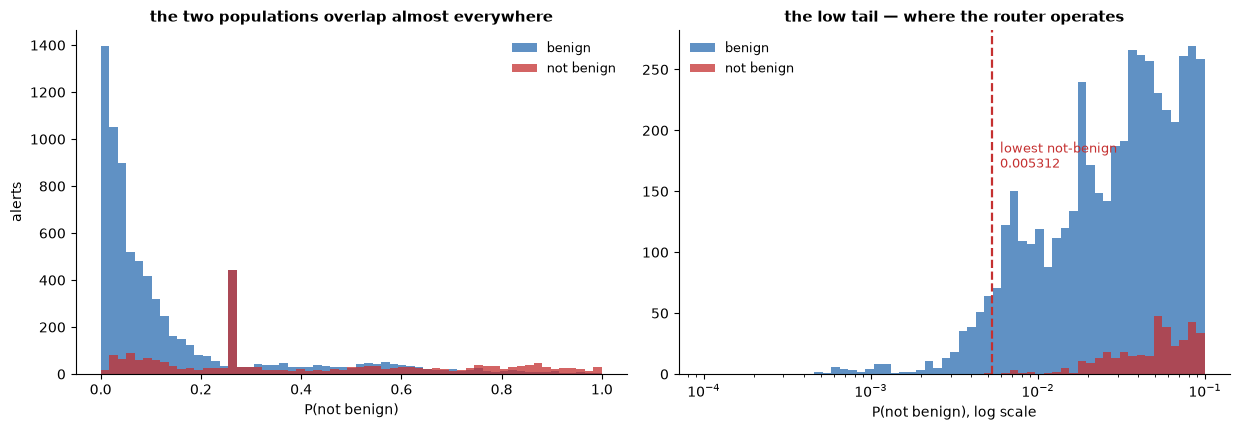

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

bins = np.linspace(0, 1, 60)
ax1.hist(benign_s, bins=bins, alpha=.75, label="benign", color="#2b6cb0")
ax1.hist(notben_s, bins=bins, alpha=.75, label="not benign", color="#c53030")
ax1.set_xlabel("P(not benign)"); ax1.set_ylabel("alerts")
ax1.set_title("the two populations overlap almost everywhere",
              fontsize=11, fontweight="bold")
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# the low tail is the only part the router uses - look at it on a log axis
lo = np.logspace(-4, -1, 60)
ax2.hist(benign_s, bins=lo, alpha=.75, label="benign", color="#2b6cb0")
ax2.hist(notben_s, bins=lo, alpha=.75, label="not benign", color="#c53030")
ax2.axvline(notben_s.min(), color="#c53030", ls="--", lw=1.6)
ax2.annotate(f"  lowest not-benign\n  {notben_s.min():.6f}",
             (notben_s.min(), ax2.get_ylim()[1]*.6), fontsize=9, color="#c53030")
ax2.set_xscale("log"); ax2.set_xlabel("P(not benign), log scale")
ax2.set_title("the low tail — where the router operates",
              fontsize=11, fontweight="bold")
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

The left panel is why the threshold cannot sit anywhere sensible-looking: the two
populations overlap across the whole range. A typical benign alert does not score
0.001 — it scores around 0.06, meaning *"probably fine, but I am not sure"*.

The right panel is the part that matters. **The dashed line is the single
lowest-scoring not-benign alert in the window**, and it alone sets the operating
point.

## 2. How a threshold is computed

Sort every alert by score, lowest first. Walk up the list. Stop at the first
not-benign one. Put the line just below it. That is the whole algorithm — it is
what `zero_miss_point` does.

In [63]:
order   = np.argsort(score_holdout)
sorted_y, sorted_s = y_holdout[order], score_holdout[order]
first_bad = int(np.argmax(sorted_y == 1))

print("walking the sorted list from the lowest score upward:\n")
for i in list(range(3)) + ["..."] + [first_bad-2, first_bad-1, first_bad, first_bad+1]:
    if i == "...":
        print(f"   {'...':>9}")
        continue
    flag = "NOT BENIGN  <-- STOP" if sorted_y[i] == 1 else "benign"
    print(f"   rank {i:6,}  score {sorted_s[i]:.6f}   {flag}")

thr = sorted_s[first_bad - 1]
print(f"\n   {first_bad:,} alerts scored below the first not-benign one")
print(f"   threshold  = {thr:.6f}")
print(f"   auto-closes {first_bad/len(y_holdout)*100:.2f}% of the queue, 0 wrong")
print(f"\n   the lowest-scoring NOT-BENIGN alert is {notben_s.min():.6f} —")
print(f"   one alert sets the entire operating point.")

walking the sorted list from the lowest score upward:

   rank      0  score 0.000470   benign
   rank      1  score 0.000471   benign
   rank      2  score 0.000577   benign
         ...
   rank    276  score 0.005289   benign
   rank    277  score 0.005300   benign
   rank    278  score 0.005312   NOT BENIGN  <-- STOP
   rank    279  score 0.005312   benign

   278 alerts scored below the first not-benign one
   threshold  = 0.005300
   auto-closes 2.86% of the queue, 0 wrong

   the lowest-scoring NOT-BENIGN alert is 0.005312 —
   one alert sets the entire operating point.


### Why the number is so small

It is not that the model is timid. It is that the region where it is *certain* is
narrow, and a few not-benign alerts score down inside it.

A miss budget is how you step past those. Allowing a handful of mistakes moves
the line past the pathological alerts and buys a lot of coverage.

In [64]:
rows = []
for budget in MISS_BUDGETS:
    share, t = zero_miss_point(y_holdout, score_holdout, budget)
    lane = score_holdout < t
    rows.append({"miss_budget": budget, "threshold": round(float(t), 6),
                 "auto_closed": int(lane.sum()),
                 "pct_of_queue": round(lane.mean()*100, 2),
                 "wrong": int(y_holdout[lane].sum())})
pd.DataFrame(rows)

,miss_budget,threshold,auto_closed,pct_of_queue,wrong
0,0,0.005300,278,2.86,0
1,1,0.006716,467,4.80,1
2,2,0.006880,500,5.14,2
3,5,0.007909,679,6.98,5
4,10,0.013498,1158,11.90,10
5,20,0.018375,1566,16.10,20
6,50,0.024645,2032,20.89,50


## 3. What confidence means

A natural assumption is that *far from the threshold* means *more confident*.
That is only true going **downward**.

The score is `P(not benign)`, so confidence is distance from **0.5**, not from the
threshold. Move up from the threshold and you head *into* uncertainty, not away
from it.

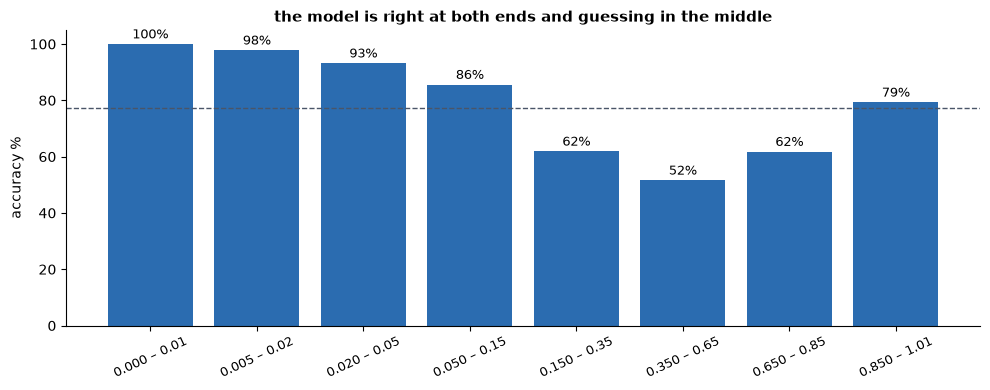

,score_band,alerts,actually_not_benign_pct,accuracy_pct
0,0.000 – 0.01,244,0.0,100.0
1,0.005 – 0.02,1480,2.2,97.8
2,0.020 – 0.05,1723,6.8,93.2
3,0.050 – 0.15,2529,14.4,85.6
4,0.150 – 0.35,1867,38.1,61.9
5,0.350 – 0.65,1060,38.7,51.6
6,0.650 – 0.85,521,61.8,61.8
7,0.850 – 1.01,304,79.3,79.3


In [65]:
bands = [(0,.005),(.005,.02),(.02,.05),(.05,.15),(.15,.35),(.35,.65),(.65,.85),(.85,1.01)]
rows = []
for lo, hi in bands:
    k = (score_holdout >= lo) & (score_holdout < hi)
    if not k.sum():
        continue
    pred = (score_holdout[k] >= 0.5).astype(int)
    rows.append({"score_band": f"{lo:.3f} – {hi:.2f}",
                 "alerts": int(k.sum()),
                 "actually_not_benign_pct": round(y_holdout[k].mean()*100, 1),
                 "accuracy_pct": round((pred == y_holdout[k]).mean()*100, 1)})
band = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(band)), band["accuracy_pct"], color="#2b6cb0")
ax.axhline(100 - y_holdout.mean()*100, color="#4a5568", ls="--", lw=1)
ax.set_xticks(range(len(band))); ax.set_xticklabels(band["score_band"], rotation=25, fontsize=9)
ax.set_ylabel("accuracy %"); ax.set_ylim(0, 105)
ax.set_title("the model is right at both ends and guessing in the middle",
             fontsize=11, fontweight="bold")
for i, v in enumerate(band["accuracy_pct"]):
    ax.text(i, v+2, f"{v:.0f}%", ha="center", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()
band

A **U**, centred on 0.5 — not on the threshold. The 0.35–0.65 band is a coin
flip, and it is the band *furthest* from the threshold in raw distance.

This gives the score a second use beyond routing. Everything above the threshold
currently goes to a human as one undifferentiated pile, and it is not one pile:

| Score | Meaning | Handling |
| --- | --- | --- |
| < threshold | certain benign | auto-close |
| threshold – 0.05 | probably benign | fast-track |
| 0.15 – 0.65 | **the model has no idea** | full investigation |
| > 0.85 | likely real | escalate first |

Sorting the human queue by score puts the genuinely ambiguous cases in front of
the right people, without touching the model or the threshold.

## 4. Calibration — run this before every deployment

**A threshold is a perishable artifact.** The one in the manifest was measured
out-of-fold across the whole training window; the alert population has moved
since, so it no longer means what it says.

The protocol is a **three-way forward split** — never shuffled, always in time
order:

| Split | Purpose |
| --- | --- |
| **train** | fit the model |
| **calibrate** | pick the threshold — on alerts the model has never seen |
| **validate** | measure what that threshold actually delivers |

Calibrating on training data gives thresholds from in-sample scores, which are
systematically overconfident. Quoting the calibration figure rather than the
validation figure overstates coverage.

In [66]:
n = len(table)
cut_a, cut_b = int(n * 0.60), int(n * 0.80)
tr_c, cal, val = table.iloc[:cut_a], table.iloc[cut_a:cut_b], table.iloc[cut_b:]

for nm, part in (("train", tr_c), ("calibrate", cal), ("validate", val)):
    print(f"  {nm:10s} {len(part):6,}  {part.t.min():%Y-%m-%d} → {part.t.max():%Y-%m-%d}  "
          f"{part[TARGET].mean()*100:5.1f}% not benign")

model_c = fit(tr_c)
s_cal, y_cal = score_of(model_c, cal), cal[TARGET].to_numpy()
s_val, y_val = score_of(model_c, val), val[TARGET].to_numpy()

print(f"\n  the score distribution itself shifts between the two windows:")
print(f"    calibrate  median {np.median(s_cal):.4f}   p5 {np.percentile(s_cal,5):.6f}")
print(f"    validate   median {np.median(s_val):.4f}   p5 {np.percentile(s_val,5):.6f}")

  train      19,456  2025-10-08 → 2026-06-03   18.2% not benign
  calibrate   6,485  2026-06-03 → 2026-08-10   21.8% not benign
  validate    6,486  2026-08-10 → 2026-09-23   23.3% not benign



  the score distribution itself shifts between the two windows:
    calibrate  median 0.0709   p5 0.005347
    validate   median 0.1095   p5 0.006522


In [67]:
rows = []
for budget in (0, 1, 2, 5, 10, 20):
    share, t = zero_miss_point(y_cal, s_cal, budget)   # chosen on calibrate
    lane = s_val < t                                    # measured on validate
    rows.append({"miss_budget": budget, "threshold": round(float(t), 6),
                 "promised_pct": round(share, 2),
                 "ACTUAL_pct": round(lane.mean()*100, 2),
                 "actual_misses": int(y_val[lane].sum())})
calib = pd.DataFrame(rows)

frozen_thr = manifest["metrics"]["operating_points"]["0"]["threshold"]
lane = s_val < frozen_thr
print(f"the FROZEN threshold {frozen_thr:.6f} applied to the validate window:")
print(f"   auto-closes {lane.mean()*100:.2f}%  ({int(y_val[lane].sum())} misses)  "
      f"— the manifest promises "
      f"{manifest['metrics']['operating_points']['0']['ai_share_pct']}%\n")
calib

the FROZEN threshold 0.001524 applied to the validate window:
   auto-closes 0.43%  (0 misses)  — the manifest promises 1.65%



,miss_budget,threshold,promised_pct,ACTUAL_pct,actual_misses
0,0,0.004118,3.32,2.11,0
1,1,0.005528,5.35,3.48,1
2,2,0.006517,6.63,5.00,1
3,5,0.007867,8.85,7.31,3
4,10,0.008345,10.12,7.86,3
5,20,0.012453,14.53,10.47,5


Two things this shows every time it is run:

**Calibration is always optimistic.** Every row under-delivers — a threshold
chosen on one window buys less coverage on the next, because the population keeps
drifting. Quote the `ACTUAL_pct` column, never `promised_pct`.

**Zero misses survives the drift.** The budget-0 threshold let nothing through on
a window it had never seen. That is the property worth protecting.

### Deploying the result

```bash
THRESHOLD=<the calibrated value> \
  .venv/bin/uvicorn app.main:app --port 8000
```

in `../model-serving`. The model does not change — only the line through its
scores. Re-run this stage monthly.